## Import libraries and load data

In [1]:
import numpy as np
from numpy.linalg import inv
import time
import math
import scipy
import scipy.integrate as scp
import scipy.linalg as la


import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter
import seaborn as sns


import pandas as pd
import pickle
import csv
import os
import sys
import copy

# Full width display (for Jupyter Notebook)
from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))

# Progress bar for loops
from tqdm import tqdm


In [2]:

def save_pkl(item, fname):
    """Saves an object to a pickle file."""
    folder = "retune2nov"
    os.makedirs(folder, exist_ok=True)  # Create folder if not exists
    path = os.path.join(folder, fname)

    with open(path, 'wb') as handle:
        pickle.dump(item, handle)

    print(f'File saved at: {path}')

def load_pkl(fname):
    """Loads an object from a pickle file."""
    folder = "retune2nov"
    path = os.path.join(folder, fname)

    with open(path, 'rb') as handle:
        return pickle.load(handle)


In [3]:
from pathlib import Path

# Project root = the folder containing pyproject.toml
PROJECT_ROOT = Path.cwd()

# Data directory
DATA_DIR = PROJECT_ROOT / "data"

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)

Project root: D:\LUXI\BiotechBioeng
Data dir: D:\LUXI\BiotechBioeng\data


In [ ]:
from pathlib import Path
import pandas as pd

# locate project data directory
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

# list dataset filenames (no absolute paths anymore)
dataset_files = [
    "CHO_T127_flask_PMJ.xlsx",
    "CHO_T127_SNS_36.5.xlsx",
    "CHO_T127_SNS_32.xlsx",
    "CHO_GS46_F_C_Inv.xlsx",
    "CHO_GS46_F_all.xlsx",
    "CHO_GS46_F_all_pl40.xlsx",
]

datasets = {}

for filename in dataset_files:
    file_path = DATA_DIR / filename
    dataset_name = file_path.stem  # file name without .xlsx

    try:
        datasets[dataset_name] = {
            "schedule": pd.read_excel(file_path, sheet_name="schedule"),
            "feed": pd.read_excel(file_path, sheet_name="feed"),
            "exp_meas": pd.read_excel(file_path, sheet_name="exp_meas"),
        }
        print(f"Loaded {dataset_name}")
    except Exception as e:
        print(f"Error loading {dataset_name}: {e}")

Loaded CHO_T127_flask_PMJ
Loaded CHO_T127_SNS_36.5
Loaded CHO_T127_SNS_32
Loaded CHO_GS46_F_C_Inv
Loaded CHO_GS46_F_all
Loaded CHO_GS46_F_all_pl40


## Model setup

#### Definition of state variables, model parameters and volume integration

In [5]:
# name of each state variable, first 10 states are measurable, last 7 states are unmeasurable NSDs
state_names = ['Xv', 'mAb', 'Glc','Amm', 'Gln','Lac', 'Glu', 'Asn']

#This is for plotting later, with units for all states
axis_names = ['Viable Cell Density (cell $L^{-1}$)', 'mAb Titre (mg $L^{-1}$)', 
             'Glucose Concentration (mM)','Ammonia Concentration (mM)', 'Glutamine Concentration (mM)', 'Lactate Concentration (mM)',
             'Glutamate Concentration (mM)', 'Asparagine Concentration (mM)']

rmse_name = ['RMSE-Viable Cell Density (cell $L^{-1}$)', 'RMSE-mAb Titre (mg $L^{-1}$)', 
             'RMSE-Glucose Concentration (mM)','RMSE-Ammonia Concentration (mM)', 'RMSE-Glutamine Concentration (mM)', 
             'RMSE-Lactate Concentration (mM)', 'RMSE-Glutamate Concentration (mM)', 'RMSE-Asparagine Concentration (mM)']

parameter_keys = ['mu_max', 'mu_d_max', 'Kglc', 'Kasn', 
                  'KIlac', 'KIamm', 'Kd_amm', 'm_lac', 'm_glc', 'Lac_max_1', 'Lac_max_2', 
                'Yx_glc', 'Yx_gln', 'Yx_glu', 'Yx_lac', 'Yx_amm', 'Yx_asn', 'Yx_asp', 'Ygln_amm', 
                  'Ylac_glc', 'Yasp_asn', 'Yasn_asp', 'm_mAb', 'YmAb_mu']


latex_labels = {
    "mu_max": r"$\mu_{\max}$",
    "mu_d_max": r"$\mu_{d,\max}$",
    "Kglc": r"$K_{\text{Glc}}$",
    "Kasn": r"$K_{\text{Asn}}$",
    "KIlac": r"$K_{I,\text{Lac}}$",
    "KIamm": r"$K_{I,\text{Amm}}$",
    "Kd_amm": r"$K_{d,\text{Amm}}$",
    "m_lac": r"$m_{\text{Lac}}$",
    "m_glc": r"$m_{\text{Glc}}$",
    "Lac_max_1": r"$Lac_{\max 1}$",
    "Lac_max_2": r"$Lac_{\max 2}$",
    "Yx_glc": r"$Y_{X,\text{Glc}}$",
    "Yx_gln": r"$Y_{X,\text{Gln}}$",
    "Yx_glu": r"$Y_{X,\text{Glu}}$",
    "Yx_lac": r"$Y_{X,\text{Lac}}$",
    "Yx_amm": r"$Y_{X,\text{Amm}}$",
    "Yx_asn": r"$Y_{X,\text{Asn}}$",
    "Yx_asp": r"$Y_{X,\text{Asp}}$",
    "Ygln_amm": r"$Y_{\text{Gln,Amm}}$",
    "Ylac_glc": r"$Y_{\text{Lac,Glc}}$",
    "Yasp_asn": r"$Y_{\text{Asp,Asn}}$",
    "Yasn_asp": r"$Y_{\text{Asn,Asp}}$",
    "m_mAb": r"$m_{\text{mAb}}$",
    "YmAb_mu": r"$Y_{\text{mAb},\mu}$"
}


# Define a dictionary mapping parameter keys to LaTeX symbols


state_num = len(state_names) # number of state variables, 8 in total
meas_num = state_num # number of measurable state variables(metabolites)

In [6]:
# Nomial model parmeters' values of shake flask CHO-T127 from Kotidis et al. 2019
mean_parameters = {
    'mu_max': 0.065,
    'mu_d_max': 0.015, #0.015    
    'Kglc': 14.0378,
    'Kasn': 2.62371,
    'KIlac': 1000,
    'KIamm': 3.16935,
    'Kd_amm': 14.2830,
    'm_lac': 1.87253e-10,
    'm_glc': 3.43293e-11,
    'Lac_max_1': 21.1983,
    'Lac_max_2': 16,
    'Yx_glc': 1.0115e9,
    'Yx_gln': 4.64127e9,
    'Yx_glu': 1.45647e10,
    'Yx_lac': 5.45539e7,
    'Yx_amm': 2.36299e9,
    'Yx_asn': 7.6824e8,
    'Yx_asp': 3.59e9,
    'Ygln_amm': 0.104524,
    'Ylac_glc': 1.56,
    'Yasp_asn': 0.126,
    'Yasn_asp': 0.1,
    'm_mAb': 4.12718e-10,
    'YmAb_mu': 3.38956e-9}

In [7]:
# Function to integrate volume changes using the loaded dataset
def volume_integration(init_volume, Fin, Fout, step_len):
    """
    Computes volume integration over time using ODE.

    Parameters:
        init_volume (float): Initial volume.
        Fin (array): Inlet flow rate (L/hr).
        step_len (array): Time step array (hours).
    
    Returns:
        np.array: Integrated volume over time.
    """
    def volume_model(t, state, fin, fout):
        """ODE function defining dV/dt = Fin - Fout"""
        return np.array([fin - fout], dtype='float64')

    # Initialize storage for volume results
    current_volume = init_volume
    volumes = [current_volume]

    # Loop over all timesteps
    for step_i in tqdm(range(len(Fin)), desc="Integrating Volume"):
        fin, fout = Fin[step_i], Fout[step_i]
        ode = scp.ode(volume_model).set_integrator('lsoda', nsteps=3000)
        ode.set_initial_value(current_volume, 0.0).set_f_params(fin, fout)
        
        # Integrate one timestep
        new_volume = ode.integrate(ode.t + step_len[step_i])
        current_volume = new_volume[0]  # Update volume
        volumes.append(current_volume)

    return np.array(volumes)

# Dictionary to store volume results
volume_results = {}

# Define initial volumes for each dataset 
initial_volumes = {
    "CHO_GS46_F_C_Inv": 0.05,
    "CHO_GS46_F_all": 0.05,
    "CHO_GS46_F_all_pl40": 0.05,
    "CHO_T127_SNS_36.5": 0.9,
    "CHO_T127_SNS_32": 0.9,
    "CHO_T127_flask_PMJ": 0.1
}

for dataset_name, data in datasets.items():
    if dataset_name in initial_volumes:  # Ensure we have an initial volume for this dataset
        init_volume = initial_volumes[dataset_name]
        Fin = data["schedule"]["Fin"].values
        Fout = data["schedule"]["Fout"].values
        step_len = np.full((len(Fin),), 0.01)  # Constant time step

        # Compute volume integration
        volume_results[dataset_name] = volume_integration(init_volume, Fin, Fout, step_len)

        print(f"✅ Completed volume integration for {dataset_name}")

print("✅ All datasets processed!")


Integrating Volume: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28800/28800 [00:00<00:00, 86976.78it/s]


✅ Completed volume integration for CHO_T127_flask_PMJ


Integrating Volume: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33142/33142 [00:00<00:00, 75914.78it/s]


✅ Completed volume integration for CHO_T127_SNS_36.5


Integrating Volume: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33142/33142 [00:00<00:00, 90890.54it/s]


...

✅ Completed volume integration for CHO_GS46_F_C_Inv


Integrating Volume: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33600/33600 [00:00<00:00, 90229.13it/s]


✅ Completed volume integration for CHO_GS46_F_all


Integrating Volume: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33600/33600 [00:00<00:00, 91423.75it/s]

✅ Completed volume integration for CHO_GS46_F_all_pl40
✅ All datasets processed!


#### Building Process Model 

In [7]:
# Calculate non-fixed model_parameters for the process model
# Input: state
# Output: model model_parameters

def model_params(state, model_parameters):
    
    Xv, mAb, Glc, Amm, Gln, Lac, Glu, Asn = state
    
    # Growth and death rate
    flim = Glc / (model_parameters['Kglc'] + Glc) * Asn / (model_parameters['Kasn'] + Asn)
    finh = (model_parameters['KIamm'] / (model_parameters['KIamm'] + Amm)) * (model_parameters['KIlac'] / (model_parameters['KIlac'] + Lac)) 
    
    mu = model_parameters['mu_max'] * flim * finh
    mu_d = model_parameters['mu_d_max'] * (Amm / (model_parameters['Kd_amm'] + Amm))
    
    # Metabolites
    Qglc = (-mu / model_parameters['Yx_glc'] - model_parameters['m_glc']) 
    Qamm = mu / model_parameters['Yx_amm'] 
    
    Qlac = (mu / model_parameters['Yx_lac'] - model_parameters['Ylac_glc'] * Qglc) * \
           (model_parameters['Lac_max_1'] - Lac) / model_parameters['Lac_max_1'] + \
           model_parameters['m_lac'] * (model_parameters['Lac_max_2'] - Lac) / model_parameters['Lac_max_2']
    Qglu = -mu / model_parameters['Yx_glu']
    Qasn = (mu * (model_parameters['Yx_asp'] - model_parameters['Yx_asn'] * model_parameters['Yasn_asp'])) / \
           (model_parameters['Yx_asn'] * model_parameters['Yx_asp']) * (model_parameters['Yasn_asp'] * model_parameters['Yasp_asn'] - 1)
    Qgln = mu / model_parameters['Yx_gln'] + model_parameters['Ygln_amm'] * Qamm
    
    #Gln_int = model_parameters['f2'] * Gln  
    
    QmAb = model_parameters['YmAb_mu'] * mu + model_parameters['m_mAb']
    
    return mu, mu_d, Qglc, Qamm, Qgln, Qlac, Qglu, Qasn, QmAb


In [8]:
def model_step(model_parameters, current_state, time, Fin_t, Fout_t, Fin_glc_t, V_t, step_len, feed):
    """
    Perform one model step using ODE integration.

    Parameters:
        model_parameters (dict): Dictionary of model parameters.
        current_state (array): Current state variables.
        time (float): Current simulation time.
        Fin_t (float): Inlet flow rate for this time step.
        Fout_t (float): Outlet flow rate for this time step.
        V_t (float): Volume for this time step.
        step_len (float): Time step for integration.
        feed (dict): Dictionary of feed concentrations (Glc, Amm, Gln, etc.).
    
    Returns:
        np.array: Updated state after one step.
    """

    def dynamic_model(t, state): 
        Xv, mAb, Glc, Amm, Gln, Lac, Glu, Asn = state
        mu, mu_d, Qglc, Qamm, Qgln, Qlac, Qglu, Qasn, QmAb = model_params(state, model_parameters)

        # Differential equations

        
        dXv = Xv * ((mu-mu_d)* V_t - Fin_t)/V_t
        dmAb = (QmAb * V_t * Xv - Fin_t* mAb )/ V_t 
        dGlc = (Fin_t * (feed["Glc"] - Glc) + Qglc * V_t * Xv + Fin_glc_t * feed["glc_conc_in_glc"]) / V_t
        dAmm = (Fin_t * (feed["Amm"] - Amm) + Qamm * V_t * Xv) / V_t
        dGln = (Fin_t * (feed["Gln"] - Gln) + Qgln * V_t * Xv) / V_t
        dLac = (Fin_t * (feed["Lac"] - Lac) + Qlac * V_t * Xv) / V_t
        dGlu = (Fin_t * (feed["Glu"] - Glu) + Qglu * V_t * Xv) / V_t
        dAsn = (Fin_t * (feed["Asn"] - Asn) + Qasn * V_t * Xv) / V_t


        return np.array([dXv, dmAb, dGlc, dAmm, dGln, dLac, dGlu, dAsn], dtype='float64')

    # Ensure no zero or negative values
    current_state = np.where(current_state <= 0, 1e-12, current_state)

    # Define tolerances: set relative tolerance and compute a vector for absolute tolerances.
    rtol = 1e-3
    # Set a minimum absolute tolerance to prevent overly strict values on small components.
    min_atol = 1e-8  
    atol_vector = np.maximum(np.abs(current_state) * rtol, min_atol)

    ode = scp.ode(dynamic_model)
    ode.set_integrator('lsoda', nsteps=3000, atol=atol_vector, rtol=rtol)
    # Alternatively, if you want to use dop853, you can adjust similarly:
    # ode.set_integrator('dop853', atol=atol_vector, rtol=1e-4, nsteps=30000)

    ode.set_initial_value(current_state, time)

    try:
        new_state = list(ode.integrate(ode.t + step_len))
    except Exception as e:
        print("LSODA failed:", e)
        new_state = current_state  # Prevent crash, return last valid state

    return np.array(new_state)


In [9]:
# Dictionary to store simulation results
simulation_results = {}
initial_conditions = {}  # Store initial conditions for each dataset

for dataset_name, data in datasets.items():
    print(f"🔄 Processing dataset: {dataset_name}")

    # Extract initial conditions from exp_meas at time 0
    exp_meas = data["exp_meas"]
    initial_state = exp_meas.iloc[0][['Xv', 'mAb', 'Glc', 'Amm', 'Gln', 'Lac', 'Glu', 'Asn']].to_dict()

    # Store initial conditions for later use
    initial_conditions[dataset_name] = initial_state

    # Extract feed concentrations
    feed = data["feed"].set_index("Metabolite")["Concentration (mM)"].to_dict()

    # Extract Fin, Fout, and Volume from dataset
    Fin = data["schedule"]["Fin"].values
    Fout = data["schedule"]["Fout"].values
    Fin_glc = data["schedule"]["Fin_glc"].values
    V = volume_results[dataset_name]

    # Set simulation parameters
    current_state = np.array(list(initial_state.values()))
    step_len = 0.01
    steps_n = len(Fin)

    # Lists to store simulation results
    time_list = [0]
    Xv_list, mAb_list, Glc_list, Amm_list, Gln_list, Lac_list, Glu_list, Asn_list = [[x] for x in current_state]

    # Loop over time steps
    for step_i in tqdm(range(steps_n), desc=f"Simulating {dataset_name}"):
        Fin_t = Fin[step_i]
        Fout_t = Fout[step_i]
        Fin_glc_t = Fin_glc[step_i]
        V_t = V[step_i]

        # Run model step
        new_state = model_step(mean_parameters, current_state, time_list[-1], Fin_t, Fout_t, Fin_glc_t, V_t, step_len, feed)

        # Update current state
        current_state = np.array(new_state)

        # Store results
        Xv_list.append(current_state[0])
        mAb_list.append(current_state[1])
        Glc_list.append(current_state[2])
        Amm_list.append(current_state[3])
        Gln_list.append(current_state[4])
        Lac_list.append(current_state[5])
        Glu_list.append(current_state[6])
        Asn_list.append(current_state[7])
        time_list.append(time_list[-1] + step_len)

    # Convert results into a structured NumPy array
    set_model = np.column_stack(( Xv_list, mAb_list, Glc_list, Amm_list, Gln_list, Lac_list, Glu_list, Asn_list))

    # Adjust the model_meas_daily selection based on time column indices
    time_exp = datasets[dataset_name]["exp_meas"]["Time (hours)"].values
    time_indices = (time_exp * 100).astype(int)  # Convert to integer indices
    time_indices = np.clip(time_indices, 0, len(set_model) - 1)  # Ensure indices are within range
    model_meas_daily = set_model[time_indices]

    # Store results in dictionary
    simulation_results[dataset_name] = {
        "full_simulation": set_model,
        "daily_simulation": model_meas_daily
    }

    print(f"✅ Model simulation completed for {dataset_name}")


🔄 Processing dataset: CHO_T127_flask_PMJ


Simulating CHO_T127_flask_PMJ: 100%|██████████████████████████████████████████| 28800/28800 [00:02<00:00, 11757.26it/s]


✅ Model simulation completed for CHO_T127_flask_PMJ
🔄 Processing dataset: CHO_T127_SNS_36.5


Simulating CHO_T127_SNS_36.5: 100%|███████████████████████████████████████████| 33142/33142 [00:02<00:00, 12884.14it/s]


✅ Model simulation completed for CHO_T127_SNS_36.5
🔄 Processing dataset: CHO_T127_SNS_32


...

✅ Model simulation completed for CHO_GS46_F_C_Inv
🔄 Processing dataset: CHO_GS46_F_all


Simulating CHO_GS46_F_all: 100%|██████████████████████████████████████████████| 33600/33600 [00:03<00:00, 11137.38it/s]


✅ Model simulation completed for CHO_GS46_F_all
🔄 Processing dataset: CHO_GS46_F_all_pl40


Simulating CHO_GS46_F_all_pl40: 100%|█████████████████████████████████████████| 33600/33600 [00:02<00:00, 11585.81it/s]

✅ Model simulation completed for CHO_GS46_F_all_pl40


In [10]:
# Function to plot simulation results vs. experimental data with error bars
def plot_simulation_vs_experiment_with_error(dataset_name, simulation_results, datasets, state_names, axis_name):
    """
    Generates plots comparing simulated vs. experimental data with error bars for biological triplicates.

    Parameters:
        dataset_name (str): Name of the dataset to plot.
        simulation_results (dict): Dictionary containing simulation outputs.
        datasets (dict): Dictionary containing experimental data.
        state_names (list): List of state variable names.
        axis_name (list): List of corresponding axis labels.
    """

    # Retrieve experimental data
    exp_meas = datasets[dataset_name]["exp_meas"]

    # Retrieve full simulation results
    sim_data = simulation_results[dataset_name]["full_simulation"]

    # Extract experimental time and simulated time
    time_exp = exp_meas["Time (hours)"].values
    time_sim = np.linspace(0, len(sim_data) * 0.01, len(sim_data))  # Ensure correct time axis

    # Create plots
    for i, state in enumerate(state_names):
        plt.figure(figsize=(8, 5))

        # Extract standard deviation if available
        if f"{state}_std" in exp_meas.columns:
            std_dev = exp_meas[f"{state}_std"].values  # Standard deviation from triplicates
            plt.errorbar(time_exp, exp_meas[state].values, yerr=std_dev, fmt='o', 
                         label="Experimental (±std)", color="red", ecolor="black", capsize=3, markersize=5)
        else:
            plt.scatter(time_exp, exp_meas[state].values, label="Experimental", color="red", marker="o")

        # Plot simulation data
        plt.plot(time_sim, sim_data[:, i], label="Simulated", linestyle="-", color="blue")

        # Formatting
        plt.xlabel("Time (hours)")
        plt.ylabel(axis_name[i])
        plt.title(f" Simulation vs. Experiment ({dataset_name})")
        plt.legend()
        plt.grid()

        # Show plot
        plt.show()

# Generate plots for all datasets
#for dataset in simulation_results.keys():
    #plot_simulation_vs_experiment_with_error(dataset, simulation_results, datasets, state_names, axis_names)


## Define the uncertainty- parameter and state covariances
1. Process covariance calculation, model and measurement discrepancy, use as general guide on tuning process noise uncertainties
2. Visualize the parameter spread, illustration only not used in EnKF later
3. Visualize the observation replicates, illustration, illustration only not used in EnKF later

In [11]:
# Dictionary to store process covariance results
process_cov_results = {}

for dataset_name in simulation_results.keys():
    #print(f"🔄 Computing process covariance for {dataset_name}")

    # Retrieve experimental data (daily measurements)
    real_obs = datasets[dataset_name]["exp_meas"].iloc[:, 1:9].values  # Exclude time column

    # Retrieve simulated daily results
    model_meas_daily = simulation_results[dataset_name]["daily_simulation"]  # Exclude time column

    # Stack the matrices along a new axis
  
    stacked_processcov_matrices = np.stack((real_obs, model_meas_daily), axis=0)

    # Compute variance along the dataset axis
    var_process = np.var(stacked_processcov_matrices, axis=0)

    # Compute mean variance per state variable
    var_process_mean = np.mean(var_process, axis=0)

    # Store results
    process_cov_results[dataset_name] = var_process_mean

    # Convert dictionary values to a NumPy array (stacking datasets)
    state_matrix = np.vstack(list(process_cov_results.values()))

    # Compute maximum value for each state across all datasets
    mean_values = np.mean(state_matrix, axis=0)

    print(f"✅ Process covariance computed for {dataset_name}:")
    print(var_process_mean)

#print("✅ All process covariances computed successfully!")

✅ Process covariance computed for CHO_T127_flask_PMJ:
[7.10091024e+16 2.74412962e+01 3.16614877e-01 3.14126894e-02
 1.05448152e-02 7.64421996e-01 1.26460998e-02 1.85589907e-03]
✅ Process covariance computed for CHO_T127_SNS_36.5:
[6.27088599e+18 8.11899990e+04 2.95759633e+02 6.41813111e-01
 3.23474957e-01 1.71515772e+00 6.25450133e-01 9.02359726e-01]
✅ Process covariance computed for CHO_T127_SNS_32:
[6.33238779e+18 9.37098283e+04 1.35539285e+02 5.78925672e-01
 2.98672679e+00 3.10691166e+01 2.53703709e-01 1.11921916e+00]
✅ Process covariance computed for CHO_GS46_F_C_Inv:
[1.57679008e+18 2.95148946e+05 4.83038658e+01 2.38582516e-01
 5.54442060e-01 2.00467622e+01 7.31602364e-01 9.12942597e-02]
✅ Process covariance computed for CHO_GS46_F_all:
[2.06408740e+18 4.06154076e+04 1.44728543e+01 8.13525950e-01
 1.44623706e+00 2.34495717e+01 1.58815252e+00 1.09134939e+01]
✅ Process covariance computed for CHO_GS46_F_all_pl40:
[5.59935227e+18 4.70467418e+04 5.00879245e+01 2.77364278e+00
 8.286044

In [12]:
# Dictionary to store standard deviations of states for each dataset
state_std_devs = {}

for dataset_name, data in datasets.items():
    exp_meas = data["exp_meas"]

    # Extract only the standard deviation columns (columns ending with '_std')
    std_columns = [col for col in exp_meas.columns if col.endswith('_std')]

    # Store as a dictionary of NumPy arrays for easy numerical operations
    state_std_devs[dataset_name] = {col: exp_meas[col].values for col in std_columns}


# Convert standard deviations to variances and rename keys from '_std' to '_var'
state_variances = {}

for dataset_name, std_dict in state_std_devs.items():
    state_variances[dataset_name] = {
        state.replace('_std', '_var'): values**2 for state, values in std_dict.items()
    }

# Display results
#state_variances



In [13]:
#parameters_ensemble_covariance
parameters_ensemble_covariance = {
    'mu_max': 0.02,       # 0.065
    'mu_d_max': 0.0035,     # 0.015
    'Kglc': 4.2,           # 14.0378
    'Kasn': 0.5,           # 2.62371
    'KIlac': 150,           # 1000
    'KIamm': 0.69,         # 3.16935
    'Kd_amm': 2.5,         # 14.283
    
    'm_lac': 2e-11,        # 1.87253e-10
    'm_glc': 3.1e-12,      # 3.43293e-11
    'Lac_max_1': 3.0,      # 21.1983
    'Lac_max_2': 2.0,      # 16
    'Yx_glc': 1.774e8,     # 1.0115e+09
    'Yx_gln': 6.033e8,     # 4.64127e+09
    'Yx_glu': 3.297e9,     # 1.45647e+10
    'Yx_lac': 2.568e7,     # 5.45539e+07
    'Yx_amm': 6.020e8,     # 2.36299e+09
    'Yx_asn': 2.077e8,    # 7.6824e+08
    'Yx_asp': 8.072e8,     # 3.59e+09
    
    'Ygln_amm': 0.030,    # 0.104524
    'Ylac_glc': 0.15,     # 1.56   #0.45
    'Yasp_asn': 0.01,     # 0.126 ##0.037
    'Yasn_asp': 0.01,    # 0.1 ##0.031
    
    'm_mAb': 9.05e-11,  # 4.12718e-10
    'YmAb_mu': 3.1e-10  # 3.38956e-09
}

In [14]:
class Visualization:
    def __init__(self, datasets_para):
        """
        Initializes the visualization class for multiple datasets.

        Parameters:
        datasets_para (dict): Dictionary containing dataset names as keys and parameter dictionaries as values.
        """
        self.datasets_para = datasets_para  # Store parameters for each dataset
        self.PX = {dataset: [] for dataset in datasets_para.keys()}  # Initialize PX storage for each dataset
        self.size_PX = {dataset: 0 for dataset in datasets_para.keys()}  # Store ensemble size per dataset

    def create_parameter_ensemble(self, ensemble_size_vis, PX_Cov):
        """
        Creates an ensemble of parameters for visualization for multiple datasets.

        Parameters:
        ensemble_size_vis (int): Number of ensemble members.
        PX_Cov (dict): Dictionary containing dataset-specific parameter covariance values.
        """
        np.random.seed(42)  # Ensure reproducibility

        for dataset in self.datasets_para.keys():
            self.size_PX[dataset] = ensemble_size_vis
            self.PX[dataset] = []

            # Generate all random values for each parameter at once
            random_values = {key: np.random.normal(loc=0, scale=PX_Cov[dataset][key], size=ensemble_size_vis) 
                             for key in self.datasets_para[dataset].keys()}

            for i in range(ensemble_size_vis):
                updated_para = self.datasets_para[dataset].copy()
                for key in self.datasets_para[dataset].keys():
                    updated_para[key] += random_values[key][i]

                self.PX[dataset].append(updated_para)

    def plot_parameter_ensemble(self, dataset_name):
        """
        Plots scatter plots for parameter ensembles of a specific dataset.

        Parameters:
        dataset_name (str): Name of the dataset to visualize.
        """
        if dataset_name not in self.PX:
            print(f"❌ Error: Dataset '{dataset_name}' not found in stored ensembles.")
            return

        keys = self.datasets_para[dataset_name].keys()
        fig, axs = plt.subplots(len(keys), 1, figsize=(10, len(keys) * 3))

        if len(keys) == 1:
            axs = [axs]

        for i, key in enumerate(keys):
            values = [param_set[key] for param_set in self.PX[dataset_name]]
            axs[i].scatter(range(self.size_PX[dataset_name]), values)
            axs[i].set_title(f'Scatter Plot for {key} ({dataset_name})')
            axs[i].set_xlabel('Ensemble Member')
            axs[i].set_ylabel(key)

        plt.tight_layout()
        plt.show()

    def plot_parameter_distributions(self, dataset_name):
        """
        Plots the distributions of parameters for a specific dataset.

        Parameters:
        dataset_name (str): Name of the dataset to visualize.
        """
        if dataset_name not in self.PX:
            print(f"❌ Error: Dataset '{dataset_name}' not found in stored ensembles.")
            return

        keys = self.datasets_para[dataset_name].keys()
        fig, axs = plt.subplots(len(keys), 1, figsize=(10, len(keys) * 3))

        if len(keys) == 1:
            axs = [axs]

        for i, key in enumerate(keys):
            values = [param_set[key] for param_set in self.PX[dataset_name]]
            sns.histplot(values, kde=True, ax=axs[i])
            axs[i].set_title(f'Distribution of {key} ({dataset_name})')
            axs[i].set_xlabel(key)
            axs[i].set_ylabel('Density')

        plt.tight_layout()
        plt.show()

# Example Usage:
datasets_para = {dataset: mean_parameters.copy() for dataset in datasets.keys()}  # Clone parameters for each dataset
PX_Cov = {dataset: parameters_ensemble_covariance.copy() for dataset in datasets.keys()}  # Clone covariance for each dataset
ensemble_size_vis = 3000

# Initialize visualization object
obj = Visualization(datasets_para)

# Generate parameter ensembles for each dataset
obj.create_parameter_ensemble(ensemble_size_vis, PX_Cov)

# Example visualization for one dataset
#obj.plot_parameter_distributions("CHO_GS46_F_C_Inv")  # Change to any dataset
#obj.plot_parameter_ensemble("CHO_GS46_F_all_pl40")  # Change dataset as needed


In [15]:
# Define explicit noise variances with simplified keys
dataset_noise_variances = {

     "CHO_T127_flask_PMJ": {
        "process_var": {
            'Xv': 1e+18, #1.015e+18,
            'mAb': 1.0e+4, 
            'Glc': 1.6e+01, 
            'Amm': 1.0, #1.33, 
            'Gln': 2.0, #2.21, 
            'Lac': 1.2, 
            'Glu': 0.2, #0.16, 
            'Asn': 0.8 #0.78
        },
        "obs_var": {
            'Xv': 3e+17, #2.79e+17,
            'mAb': 1.5e+3, #1.49e+03,
            'Glc': 5.0, #4.89,
            'Amm': 0.1, #0.08685,
            'Gln': 0.1, #0.126,
            'Lac': 1.2, #1.21,
            'Glu': 0.004, #3.453e-03,
            'Asn': 0.25 #0.03
        }
    },

    
     "CHO_T127_SNS_36.5": {
        "process_var": {
            'Xv': 1.0e+19,
            'mAb': 1.0e+05,
            'Glc': 1.6e+01,
            'Amm': 1.0,
            'Gln': 4.0, #4.42,
            'Lac': 1.2, #12
            'Glu': 0.2, #0.164,
            'Asn': 0.8 #0.78
        },
        "obs_var": {
            'Xv': 5e+17,
            'mAb': 1.5e+03,
            'Glc': 5.0, 
            'Amm': 0.1, #0.08685,
            'Gln': 0.1, #0.126,
            'Lac': 1.2,
            'Glu': 0.004,
            'Asn': 0.25 #0.252
        }
    },
      "CHO_T127_SNS_32": {
        "process_var": {
            'Xv': 2.0e+19,
            'mAb': 1.0e+05,
            'Glc': 9.0e+02, #9.6e+01,
            'Amm': 6.0, #6.328,
            'Gln': 4.0, #4.42,
            'Lac': 5.0, #5.2,
            'Glu': 1.6, #1.64,
            'Asn': 5.0, #4.78
        },
        "obs_var": {
            'Xv': 3e+17,
            'mAb': 1.5e+03,
            'Glc': 5.0, #4.89, #2.896,
            'Amm': 0.2, #0.1685,
            'Gln': 0.1, #0.126,
            'Lac': 0.5, #0.51,
            'Glu': 0.04,
            'Asn': 0.25 #0.252 
        }
    },
    
      "CHO_GS46_F_C_Inv": {
        "process_var": {   
 
            'Xv': 2.0e+19,
            'mAb': 1.0e+05,
            'Glc': 9.6e+01,
            'Amm': 6.0,
            'Gln': 4.0,
            'Lac': 5.0,
            'Glu': 1.6, #1.6,
            'Asn': 3.0 #2.78
        },
        "obs_var": {
            'Xv': 3e+17,
            'mAb': 1.5e+03,
            'Glc': 5.0,
            'Amm': 0.1, #0.08685,
            'Gln': 0.1,
            'Lac': 0.2,
            'Glu': 0.004, #0.04
            'Asn': 0.025 #0.0152
        }
    },
      "CHO_GS46_F_all": {
        "process_var": {
            'Xv': 2.0e+19,
            'mAb': 1.0e+05,
            'Glc': 9.6e+01,
            'Amm': 6.0,
            'Gln': 4.0,
            'Lac': 5.0,
            'Glu': 1.6,
            'Asn': 3.0 #2.78
        },
        "obs_var": {
            'Xv': 3e+17,
            'mAb': 1.5e+03,
            'Glc': 5.0,
            'Amm': 0.1, #0.08685,
            'Gln': 0.1, #0.0526, #4.026,
            'Lac': 0.2,
            'Glu': 0.08,
            'Asn': 0.025
        }
    },
    "CHO_GS46_F_all_pl40": {
        "process_var": {
            'Xv': 2.0e+19,
            'mAb': 1.0e+05,
            'Glc': 9.6e+01,
            'Amm': 6.0,
            'Gln': 4.0,
            'Lac': 5.0,
            'Glu': 1.4,
            'Asn': 3.0
        },
        "obs_var": {
            'Xv': 3e+17,
            'mAb': 1.5e+03,
            'Glc': 5.0,
            'Amm': 0.5, #0.8685,
            'Gln': 0.1,
            'Lac': 0.2, #0.21,
            'Glu': 0.04,#0.04
            'Asn': 0.025 #0.0352
        }
    }
}


In [16]:
# Updated ObsReplicates class with integrated T_model generation
class ObsReplicates:
    def __init__(self, datasets, state_num, dataset_noise_variances, ensemble_sizes):
        """
        Initializes the observation replicates class for multiple datasets.

        Parameters:
        datasets (dict): Dictionary containing dataset names as keys and dataset data as values.
        state_num (int): Number of measurable states.
        dataset_noise_variances (dict): Dictionary containing noise variances per dataset.
        ensemble_sizes (dict): Dictionary specifying the ensemble size for each dataset.
        """
        self.datasets = datasets
        self.state_num = state_num
        self.dataset_noise_variances = dataset_noise_variances
        self.ensemble_sizes = ensemble_sizes
        self.Z = {}
        self.T_models = self.generate_T_models()

    def generate_T_models(self, dt_model=0.01):
        """
        Generates T_model for all datasets based on their Fin schedule.

        Parameters:
        dt_model (float): Model time step in hours (default is 0.01 hours).

        Returns:
        dict: Dictionary containing T_model for each dataset.
        """
        T_models = {}
        for dataset, data in self.datasets.items():
            Fin = data["schedule"]["Fin"].values
            t_total = len(Fin) / 100  # Convert to total hours
            N_model = int(t_total / dt_model)  # Number of model steps
            T_models[dataset] = np.linspace(0, t_total, N_model + 1)
        return T_models

    def create_noisy_observations(self):
        """
        Generates noisy observation replicates for all datasets.
        """
        np.random.seed(42)

        for dataset, data in self.datasets.items():
            real_obs = data["exp_meas"][['Xv', 'mAb', 'Glc', 'Amm', 'Gln', 'Lac', 'Glu', 'Asn']].values
            N_meas_real = real_obs.shape[0]  # Dynamically determine N_meas_real from exp_meas

            obs_var = np.array(list(self.dataset_noise_variances[dataset]["obs_var"].values()))

            # Get dataset-specific ensemble size
            ensemble_size = self.ensemble_sizes.get(dataset, 50)  # Default to 50 if not provided

            # Generate noise with the correct shape
            noise = np.random.normal(0, np.sqrt(obs_var), size=(ensemble_size, N_meas_real, self.state_num))

            # Add noise to real observations
            self.Z[dataset] = real_obs + noise

    def plot_noisy_observations(self, dataset_name, set_model):
        """
        Plots noisy observations for a specific dataset.

        Parameters:
        dataset_name (str): Name of the dataset to visualize.
        set_model_met (array): Model-simulated metabolite states.
        """
        if dataset_name not in self.Z:
            print(f"❌ Error: Dataset '{dataset_name}' not found.")
            return

        data = self.datasets[dataset_name]
        real_obs = data["exp_meas"][['Xv', 'mAb', 'Glc', 'Amm', 'Gln', 'Lac', 'Glu', 'Asn']].values
        real_obs_time = data["exp_meas"]["Time (hours)"].values
        obs_replicates = self.Z[dataset_name]

        T_model = self.T_models[dataset_name]  # Get dataset-specific T_model

        fig, axs = plt.subplots(self.state_num, 1, figsize=(8, 26))

        for i, ax in enumerate(axs):
            ax.plot(T_model, set_model[:, i], '-r', label='Model')
            ax.plot(real_obs_time, real_obs[:, i], 'o', color='purple', label='Measurement')

            for j in range(obs_replicates.shape[0]):
                ax.scatter(real_obs_time, obs_replicates[j, :, i], color='grey', s=10, alpha=0.5)

            ax.set_xlabel('Hour')
            ax.set_ylabel(axis_names[i])
            #ax.legend(['Model', 'Measurement', 'Perturbed Observations'])

        plt.tight_layout()
        plt.show()


# Example Usage:
ensemble_sizes = {
    "CHO_GS46_F_C_Inv": 50,
    "CHO_GS46_F_all": 50,
    "CHO_GS46_F_all_pl40": 50,
    "CHO_T127_flask_PMJ": 50,
    "CHO_T127_SNS_32": 50,
    "CHO_T127_SNS_36.5": 50
}

# Initialize observation replicates object using dataset-specific ensemble sizes
obs_obj = ObsReplicates(datasets, state_num, dataset_noise_variances, ensemble_sizes)

# Generate noisy observations for all datasets
obs_obj.create_noisy_observations()

# Example visualization for one dataset
#obs_obj.plot_noisy_observations("CHO_T127_SNS_36.5", simulation_results["CHO_T127_SNS_36.5"]["full_simulation"])
#obs_obj.plot_noisy_observations("CHO_T127_SNS_32", simulation_results["CHO_T127_SNS_32"]["full_simulation"])
#obs_obj.plot_noisy_observations("CHO_GS46_F_C_Inv", simulation_results["CHO_GS46_F_all"]["full_simulation"])
#obs_obj.plot_noisy_observations("CHO_GS46_F_all", simulation_results["CHO_GS46_F_all"]["full_simulation"])
#obs_obj.plot_noisy_observations("CHO_GS46_F_all_pl40", simulation_results["CHO_GS46_F_all_pl40"]["full_simulation"])
#obs_obj.plot_noisy_observations("CHO_T127_flask_PMJ", simulation_results["CHO_T127_SNS_32"]["full_simulation"])


## Design Ensemble Kalman Filter


In [17]:
class EnKF_ParameterEstimation:
    def __init__(self, dataset_name, datasets, dataset_noise_variances, dt_model):
        """
        Initializes the EnKF parameter estimation for a specific dataset.

        Parameters:
        dataset_name (str): Name of the dataset.
        datasets (dict): Dictionary of datasets.
        dataset_noise_variances (dict): Noise variance values for each dataset.
        dt_model (float): Time step for the model.
        """
        np.random.seed(42)
        self.dataset_name = dataset_name
        self.datasets = datasets
        self.dataset_noise_variances = dataset_noise_variances
        self.dt = dt_model  # Model time step
        
        # State and ensemble variables
        exp_meas = datasets[dataset_name]["exp_meas"]
        self.x = exp_meas.iloc[0][['Xv', 'mAb', 'Glc', 'Amm', 'Gln', 'Lac', 'Glu', 'Asn']].values  # Initial state
        self.X = None  # State ensemble
        self.size_X = None  # Number of ensemble members for states
        
        self.z = exp_meas[['Xv', 'mAb', 'Glc', 'Amm', 'Gln', 'Lac', 'Glu', 'Asn']].values  # Observations
        self.Z = None  # Observation ensemble replicates

        # Parameter-related variables
        self.para = mean_parameters.copy()  # Nominal parameter values
        self.PX = None  # Parameter ensemble
        self.size_PX = None  # Number of ensemble members for each parameter
        self.Kp = None  # Kalman gain for parameters
        self.Ks = None  # Kalman gain for states
        self.theta = None  # Cross-covariance matrix

        
         # Initialize matrices
        self.P = None  # Process covariance
        self.kQ = None  # Adjusted process covariance factor
        self.kR = None # Measurement covariance factor 
        self.Q = None  # Adjusted process covariance
        self.R = None # Measurement covariance
        self.fx = None  # Model step function
        self.H = np.eye(len(self.x))


        # Storage for results
        self.X_forecast_for_parameters_records = []
        self.X_forecast_for_states_records = []
        self.X_posterior_records = []
        self.PX_records = []
        self.para_records = []
    
    def create_parameters_ensemble(self, ensemble_size, PX_Cov):
        """Generates a parameter ensemble with Gaussian perturbations."""
        self.size_PX = ensemble_size
        self.PX = []

        np.random.seed(42)
        random_values = {key: np.random.normal(0, PX_Cov[key], ensemble_size) for key in self.para.keys()}
        
        for i in range(self.size_PX):
            perturbed_para = self.para.copy()
            for key in self.para.keys():
                perturbed_para[key] += random_values[key][i]
                perturbed_para[key] = max(1e-12, perturbed_para[key])  # Ensure no negative values
            self.PX.append(perturbed_para)
    
    def create_states_ensemble(self, ensemble_size):
        """Creates a state ensemble with Gaussian noise."""
        self.size_X = ensemble_size
        np.random.seed(42)
        self.X = np.random.multivariate_normal(self.x, self.Q, ensemble_size)
        # Replace negative values with zero
        self.X = np.where(self.X < 0, 1e-12, self.X)
    
    def create_noisy_observations(self, ensemble_size):
        """Generates noisy observations."""
        np.random.seed(42)
        noise_samples = np.random.multivariate_normal(np.zeros(len(self.x)), self.R, (ensemble_size, len(self.z)))
        self.Z = [self.z + noise for noise in noise_samples]

         # Replace negative values with zero
        self.Z = [np.where(z < 0, 1e-12, z) for z in self.Z]
    
    def forecast_for_parameters(self, controls):

        Fin_t, Fout_t, Fin_glc_t, V_t, feed = controls
        """Predicts the next state using the model step."""
        X_new = []
        for n, x in enumerate(self.X):
            px = self.PX[n]
            X_new.append(self.fx(px, x, 0.0, Fin_t, Fout_t, Fin_glc_t, V_t, self.dt, feed))

        np.random.seed(42)
        self.X = np.array(X_new) + np.random.multivariate_normal(np.zeros(len(self.x)), self.Q, self.size_X)
        self.X = np.where(self.X < 0, 1e-12, self.X)
        self.x = np.mean(self.X, axis=0)

        for key in self.PX[0].keys():
            values = [d[key] for d in self.PX]
            self.para[key] = np.mean(values)
        
        self.X_forecast_for_parameters_records.append(self.X.copy().tolist())
    
    def forecast_for_states(self, controls):
        """Performs state forecast using the model."""

        Fin_t, Fout_t, Fin_glc_t, V_t, feed = controls
        X_new = []
        for n, x in enumerate(self.X):
            px = self.PX[n]
            X_new.append(self.fx(px, x, 0.0, Fin_t, Fout_t, Fin_glc_t, V_t, self.dt, feed))

        np.random.seed(42)
        self.X = np.array(X_new) + np.random.multivariate_normal(np.zeros(len(self.x)), self.Q, self.size_X)
        self.X = np.where(self.X < 0, 1e-12, self.X)
        self.x = np.mean(self.X, axis=0)

        for key in self.PX[0].keys():
            values = [d[key] for d in self.PX]
            self.para[key] = np.mean(values)

        self.X_forecast_for_states_records.append(self.X.copy().tolist())


    def forecast_long(self, controls, current_state, current_para):
        Fin_t, Fout_t, Fin_glc_t, V_t, feed = controls

        # Predict the next state using the model function
        new_state = self.fx(current_para, current_state, 0.0, Fin_t, Fout_t, Fin_glc_t, V_t, self.dt, feed)

        # Add process noise (mean state, single step)
        np.random.seed(42)
        new_state += np.random.multivariate_normal(np.zeros(len(self.x)), self.Q)

        return new_state


    def parameters_update(self, time_index):
        """Updates the parameter ensemble using Kalman filtering."""
        E = self.X - self.x
        self.P = E.T @ E / (self.size_X - 1)

        PX_matrix = np.array([[d[key] for key in d] for d in self.PX])
        para_matrix = np.array(list(self.para.values()))

        self.theta = np.dot((PX_matrix - para_matrix).T, self.X - self.x) / (self.size_PX - 1)
        self.Kp = self.theta @ self.H.T @ inv(self.H @ self.P @ self.H.T + self.R)

        PX_matrix_updated = []
        for param, z, x in zip(self.PX, self.Z, self.X):
            updated_member = np.array(list(param.values())) + self.Kp @ (z[time_index] - self.H @ x)
            PX_matrix_updated.append(updated_member)

        self.PX = [dict(zip(self.para.keys(), row)) for row in PX_matrix_updated]
        # Ensure nonnegative parameters for each ensemble member.
        self.PX = [{k: max(1e-12, v) for k, v in member.items()} for member in self.PX]
        self.PX_records.append(self.PX)

        for key in self.PX[0].keys():
            values = [d[key] for d in self.PX]
            self.para[key] = np.mean(values)

        self.para_records.append(self.para.copy())

    def states_update(self, time_index):
        """Updates the state ensemble using Kalman filtering."""
        mean_x = np.mean(self.X, axis=0)
        E = self.X - mean_x
        self.P = E.T @ E / (self.size_X - 1)

        self.Ks = self.P @ self.H.T @ inv(self.H @ self.P @ self.H.T + self.R)
        X_updated = [x + self.Ks @ (z[time_index] - self.H @ x) for x, z in zip(self.X, self.Z)]

        self.X = np.array(X_updated)
        self.X = np.where(self.X < 0, 1e-12, self.X)
        self.X_posterior_records.append(self.X.copy().tolist())
        self.x = np.mean(self.X, axis=0)


In [18]:
def run_enkf_with_tuning(datasets, dataset_noise_variances, volume_results, ensemble_sizes):
    """
    Runs the EnKF parameter estimation process across multiple datasets and ensemble sizes.
    
    Parameters:
        datasets (dict): Dictionary containing dataset information.
        dataset_noise_variances (dict): Noise variance dictionary for each dataset.
        volume_results (dict): Dictionary containing computed volume over time for each dataset.
        ensemble_sizes (list): List of ensemble sizes to test.
    
    Returns:
        ensemble_tuning (dict): Simulation trajectories (ensemble means) for each dataset and ensemble size.
        rmse_results (dict): RMSE values for each dataset and ensemble size.
        computation_times (dict): Computation time for each dataset and ensemble size.
        PX_records_all (dict): Parameter ensemble evolution records for each dataset and ensemble size.
        para_records_all (dict): Nominal parameter evolution records for each dataset and ensemble size.
        X_forecast_for_parameters_records_all (dict): State ensemble (parameters forecast) records.
        X_forecast_for_states_records_all (dict): State ensemble (states forecast) records.
        X_posterior_records_all (dict): Posterior state ensemble records.
        Z_all (dict): Observation ensemble records.
    """
    ensemble_tuning = {}      # Simulation trajectories (ensemble mean)
    rmse_results = {}         # RMSE values
    computation_times = {}    # Computation times
    
    # Additional records to be returned:
    PX_records_all = {}       # Parameter ensemble evolution (enkf.PX_records)
    para_records_all = {}     # Nominal parameter evolution (enkf.para_records)
    X_forecast_for_parameters_records_all = {}  # State ensemble forecast for parameters
    X_forecast_for_states_records_all = {}        # State ensemble forecast for states
    X_posterior_records_all = {}  # Posterior state ensemble evolution
    Z_all = {}                # Observation ensemble
    
    # Loop over each dataset
    for dataset_name, data in datasets.items():
        print(f"🔄 Running EnKF for dataset: {dataset_name}")

        # Extract dataset-specific values from schedule and experimental measurements
        Fin = data["schedule"]["Fin"].values
        Fout = data["schedule"]["Fout"].values
        Fin_glc = data["schedule"]["Fin_glc"].values
        V = volume_results[dataset_name]  # Precomputed volume
        
        # Define simulation time steps:
        time_steps_A = [round(i * 0.01, 2) for i in range(len(Fin))]
        time_steps_B = [round(t, 2) for t in data["exp_meas"]["Time (hours)"].values]
        
        # Extract initial state from experimental measurements
        state_init = data["exp_meas"].iloc[0][['Xv', 'mAb', 'Glc', 'Amm', 'Gln', 'Lac', 'Glu', 'Asn']].values
        
        # Obtain experimental measurement indices (scaled to model time resolution)
        time_exp = data["exp_meas"]["Time (hours)"].values
        time_indices = (time_exp * 100).astype(int)
        time_indices = np.clip(time_indices, 0, len(Fin) - 1)
        
        # Extract feed concentrations (ensure keys match those expected in model_step)
        feed = data["feed"].set_index("Metabolite")["Concentration (mM)"].to_dict()
        
        # Initialize result dictionaries for this dataset
        ensemble_tuning[dataset_name] = {}
        rmse_results[dataset_name] = {}
        computation_times[dataset_name] = {}
        PX_records_all[dataset_name] = {}
        para_records_all[dataset_name] = {}
        X_forecast_for_parameters_records_all[dataset_name] = {}
        X_forecast_for_states_records_all[dataset_name] = {}
        X_posterior_records_all[dataset_name] = {}
        Z_all[dataset_name] = {}
        
        # Loop over each ensemble size for the current dataset
        for ensemble_size in ensemble_sizes:
            print(f"⚙️ Running EnKF with ensemble size: {ensemble_size} for {dataset_name}")
            start_time = time.time()

            kQ = kQ_dict[dataset_name]
            kR = kR_dict[dataset_name]
            
            Q = kQ * np.diag(list(dataset_noise_variances[dataset_name]["process_var"].values()))#1E-8 1.5 ERROR
            R = kR * np.diag(list(dataset_noise_variances[dataset_name]["obs_var"].values()))
            H = np.eye(len(state_init))
            real_obs = data["exp_meas"].iloc[:, 1:9].values  # Adjust column indices if needed
            dt_kf = 0.01
            state_num = len(state_init)
            
            # Initialize the EnKF object. (Assuming your new class signature is as defined earlier.)
            enkf = EnKF_ParameterEstimation(dataset_name, datasets, dataset_noise_variances, dt_model=dt_kf)
            
            # Initialize EnKF internal variables (as in the old version):
            enkf.PX = []                     # Parameter ensemble
            enkf.PX_records = []             # Record of parameter ensemble over time
            enkf.para = mean_parameters.copy()  # Nominal parameter values
            enkf.para_records = [mean_parameters.copy()]
            enkf.x = state_init.copy()       # Current state (ensemble mean)
            
            # Set covariance matrices and observation information
            enkf.Q = Q.copy()
            enkf.H = H.copy()
            enkf.R = R.copy()
            enkf.z = real_obs.copy()
            enkf.Z = []                      # Noisy observation ensemble (will be created shortly)
            
            # Set the model step function and associated parameters
            enkf.fx = model_step
            enkf.dt = dt_kf
            enkf.num_x = state_num
            
            
            
            # Create the parameter and state ensembles and generate noisy observations
            enkf.create_parameters_ensemble(ensemble_size, parameters_ensemble_covariance)
            enkf.create_states_ensemble(ensemble_size)
            enkf.create_noisy_observations(ensemble_size)


            # Initialize records for forecast and update steps
            enkf.X_forecast_for_parameters_records = []  # For parameter forecast tracking
            enkf.X_forecast_for_states_records = []        # For state forecast tracking
            enkf.X_posterior_records = []                  # For posterior state ensemble tracking
            enkf.PX_records.append(enkf.PX)
            
            # Initialize storage for the simulation trajectory (ensemble mean)
            set_EnKF = [state_init.copy()]
            
            # Main loop over simulation time steps
            for idx_A, step_A in enumerate(tqdm(time_steps_A, desc=f"Loop A (Ensemble {ensemble_size})")):
                # Check if the current simulation time corresponds to an experimental measurement
                if step_A in time_steps_B:
                    idx_B = np.searchsorted(time_steps_B, step_A)
                    print('Updating parameters on Day', step_A/24)
                    # Forecast for parameters using current controls; note that feed is part of the controls tuple.
                    enkf.forecast_for_parameters((Fin[idx_A], Fout[idx_A], Fin_glc[idx_A], V[idx_A], feed))
                    enkf.parameters_update(idx_B)
                    #enkf.PX_records.append(enkf.PX)
                
                # Forecast for states using the current controls
                enkf.forecast_for_states((Fin[idx_A], Fout[idx_A], Fin_glc[idx_A], V[idx_A], feed))
                
                # Update state ensemble when the simulation time matches experimental time
                for idx_B, step_B in enumerate(time_steps_B):
                    if step_A == step_B:
                        
                        enkf.states_update(idx_B)
                
                # Record the current ensemble mean state
                set_EnKF.append(enkf.x.copy())
            
            # Convert the simulation trajectory to a NumPy array for further analysis
            set_EnKF = np.array(set_EnKF)
            ensemble_tuning[dataset_name][ensemble_size] = set_EnKF
            
            # Compute RMSE (using the measurement time indices)
            rmse_results[dataset_name][ensemble_size] = np.sqrt((set_EnKF[time_indices] - data["exp_meas"].iloc[:, 1:9].values) ** 2)
            
            # Store computation time for this ensemble size and dataset
            computation_times[dataset_name][ensemble_size] = time.time() - start_time
            
            # Save the additional internal records for this run:
            para_records_all[dataset_name][ensemble_size] = enkf.para_records
            X_forecast_for_parameters_records_all[dataset_name][ensemble_size] = enkf.X_forecast_for_parameters_records
            X_forecast_for_states_records_all[dataset_name][ensemble_size] = enkf.X_forecast_for_states_records
            X_posterior_records_all[dataset_name][ensemble_size] = enkf.X_posterior_records
            Z_all[dataset_name][ensemble_size] = enkf.Z
            PX_records_all[dataset_name][ensemble_size] = enkf.PX_records

    return (ensemble_tuning, rmse_results, computation_times, 
            PX_records_all, para_records_all, 
            X_forecast_for_parameters_records_all, 
            X_forecast_for_states_records_all, 
            X_posterior_records_all, Z_all)


## Dual State and Parameter Estimation - EnKF Implementation

In [ ]:
# Template for process noise scaling factors (kQ) for each dataset
kQ_dict = {
    "CHO_GS46_F_C_Inv": 1e-9,
    "CHO_GS46_F_all": 1e-9,
    "CHO_GS46_F_all_pl40": 1e-9,
    "CHO_T127_SNS_36.5": 1e-9,
    "CHO_T127_SNS_32": 1e-9,
    "CHO_T127_flask_PMJ": 1e-9
}

# Template for measurement noise scaling factors (kR) for each dataset
kR_dict = {
    "CHO_GS46_F_C_Inv": 1.0,
    "CHO_GS46_F_all": 1.0,
    "CHO_GS46_F_all_pl40": 1.0,
    "CHO_T127_SNS_36.5": 1.0,
    "CHO_T127_SNS_32": 1.0,
    "CHO_T127_flask_PMJ": 1.0
}


In [21]:
#ensemble_sizes = [100] #done
ensemble_sizes = [10, 25, 50, 75, 100] #done
#ensemble_sizes = [50] #done
(ensemble_tuning, 
    rmse_results, 
    computation_times, 
    PX_records_all, 
    para_records_all, 
    X_forecast_for_parameters_records_all, 
    X_forecast_for_states_records_all, 
    X_posterior_records_all, 
    Z_all) = run_enkf_with_tuning(datasets, dataset_noise_variances, volume_results, ensemble_sizes)


🔄 Running EnKF for dataset: CHO_T127_flask_PMJ
⚙️ Running EnKF with ensemble size: 10 for CHO_T127_flask_PMJ


Loop A (Ensemble 10):   0%|                                                        | 56/28800 [00:00<00:52, 551.34it/s]

Updating parameters on Day 0.0


Loop A (Ensemble 10):   9%|████▋                                                 | 2480/28800 [00:04<00:43, 603.33it/s]

Updating parameters on Day 1.0


...

Loop A (Ensemble 100):  86%|█████████████████████████████████████████████▍       | 28811/33600 [06:11<01:02, 76.88it/s]

Updating parameters on Day 12.0


Loop A (Ensemble 100):  93%|█████████████████████████████████████████████████▏   | 31210/33600 [06:42<00:32, 72.46it/s]

Updating parameters on Day 13.0


Loop A (Ensemble 100): 100%|█████████████████████████████████████████████████████| 33600/33600 [07:13<00:00, 77.56it/s]


In [33]:
# Save each dataset separately
save_pkl(ensemble_tuning, 'ensemble_tuning.pkl')
save_pkl(rmse_results, 'rmse_results.pkl')
save_pkl(computation_times, 'computation_times.pkl')
save_pkl(PX_records_all, 'PX_records_all.pkl')
save_pkl(para_records_all, 'para_records_all.pkl')
save_pkl(X_forecast_for_parameters_records_all, 'X_forecast_for_parameters_records_all.pkl')
save_pkl(X_forecast_for_states_records_all, 'X_forecast_for_states_records_all.pkl')
save_pkl(X_posterior_records_all, 'X_posterior_records_all.pkl')
save_pkl(Z_all, 'Z_all.pkl')
save_pkl(dataset_noise_variances, 'dataset_noise_variances.pkl')  
save_pkl(kQ_dict, 'kQ_dict.pkl')
save_pkl(kR_dict, 'kR_dict.pkl')

File saved at: retune2nov\ensemble_tuning.pkl
File saved at: retune2nov\rmse_results.pkl
File saved at: retune2nov\computation_times.pkl
File saved at: retune2nov\PX_records_all.pkl
File saved at: retune2nov\para_records_all.pkl
File saved at: retune2nov\X_forecast_for_parameters_records_all.pkl
File saved at: retune2nov\X_forecast_for_states_records_all.pkl
File saved at: retune2nov\X_posterior_records_all.pkl
File saved at: retune2nov\Z_all.pkl
File saved at: retune2nov\dataset_noise_variances.pkl
File saved at: retune2nov\kQ_dict.pkl
File saved at: retune2nov\kR_dict.pkl


In [20]:
# Load all datasets from their respective pickle filesSD

# Load all objects
ensemble_tuning = load_pkl('ensemble_tuning.pkl')
rmse_results = load_pkl('rmse_results.pkl')
computation_times = load_pkl('computation_times.pkl')
PX_records_all = load_pkl('PX_records_all.pkl')
para_records_all = load_pkl('para_records_all.pkl')
X_forecast_for_parameters_records_all = load_pkl('X_forecast_for_parameters_records_all.pkl')
#X_forecast_for_states_records_all = load_pkl('X_forecast_for_states_records_all.pkl')
X_posterior_records_all = load_pkl('X_posterior_records_all.pkl')
Z_all = load_pkl('Z_all.pkl')
dataset_noise_variances = load_pkl('dataset_noise_variances.pkl')
kQ_dict = load_pkl('kQ_dict.pkl')
kR_dict = load_pkl('kR_dict.pkl')

print("All datasets successfully loaded!")


All datasets successfully loaded!


#### Full measurement trajectories

In [21]:
def plot_ensemble_simulation_all(simulation_results, datasets, ensemble_tuning, axis_name):
    """
    Plots the simulation results for multiple datasets using all available ensemble sizes.

    Parameters:
        simulation_results (dict): Dictionary containing model simulation results.
        datasets (dict): Dictionary containing experimental measurements.
        ensemble_tuning (dict): Dictionary containing EnKF simulation results.
        axis_name (list): List of axis labels (one per state).
    """
    sns.set(style="white", context="talk")  # Use Seaborn style for presentation

    for dataset_name in simulation_results.keys():
        print(f"📊 Plotting results for {dataset_name}...")

        # Extract model simulation results
        set_model = simulation_results[dataset_name]["full_simulation"]
        T_model = np.linspace(0, len(set_model) * 0.01, len(set_model))

        # Extract experimental data
        exp_meas = datasets[dataset_name]["exp_meas"]
        real_obs_time = exp_meas["Time (hours)"].values
        real_obs = exp_meas.iloc[:, 1:].values  # All columns except "Time (hours)"

        # Iterate over all ensemble sizes in the dataset
        for ensemble_size, set_EnKF in ensemble_tuning[dataset_name].items():
            num_states = set_EnKF.shape[1]

            for i in range(num_states):
                plt.figure(figsize=(8, 6))

                # Plot reference model (Kotidis2019) trajectory
                sns.lineplot(x=T_model, y=set_model[:, i],
                             color='maroon', label='Kotidis 2019 Model', linewidth=4)

                # Plot experimental measurements
                sns.scatterplot(x=real_obs_time, y=real_obs[:, i],
                                color='orange', label='Experimental Measurements', s=100)

                # Plot EnKF simulation for this ensemble size
                sns.lineplot(x=T_model, y=set_EnKF[:, i],
                             label=f'EnKF (Ensemble {ensemble_size})', linewidth=2)

                plt.xlabel('Time (hours)')
                plt.ylabel(axis_name[i])
                plt.title(f"{dataset_name} - {axis_name[i]} (Ensemble Size: {ensemble_size})")
                plt.legend(loc='best', frameon=False)
                plt.tight_layout()
                plt.show()

# Example usage:
#plot_ensemble_simulation_all(simulation_results, datasets, ensemble_tuning, axis_names)


## Plot the ensemble tuning results to find best ensemble size

In [22]:
def plot_rmse_variance_and_computation_time_all(rmse_results, computation_times, 
                                              datasets_to_include=None, 
                                              exclude_ensemble_sizes=None,
                                              custom_titles=None,
                                              save_path="ensemble_tuning.png"):
    if exclude_ensemble_sizes is None:
        exclude_ensemble_sizes = []
        
    if datasets_to_include is None:
        datasets_to_include = list(rmse_results.keys())
        
    if custom_titles is None:
        custom_titles = {ds: ds for ds in datasets_to_include}
    
    n_plots = len(datasets_to_include)
    ncols = min(n_plots, 3)
    nrows = math.ceil(n_plots / ncols)
    
    labels = [f"({chr(97+i)})" for i in range(n_plots)]
    
    sns.set_style("white")
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 10))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = np.array(axes).flatten()
    
    for idx, dataset_name in enumerate(datasets_to_include):
        ax1 = axes[idx]
        comp_times_dict = computation_times[dataset_name]
        
        ensemble_sizes = []
        rmse_scores = []
        rmse_stds = []
        comp_times = []
        index = 0
        
        for ensemble_size, rmse in rmse_results[dataset_name].items():
            if ensemble_size in exclude_ensemble_sizes:
                continue
            
            normalized_rmse = rmse[:, index]   
            rmse_std = np.std(rmse[:,index], axis=0)
            
            ensemble_sizes.append(ensemble_size)
            rmse_scores.append(np.mean(normalized_rmse))
            rmse_stds.append(rmse_std)
            comp_times.append(comp_times_dict[ensemble_size])
        
        ax1.plot(ensemble_sizes, rmse_scores, marker='o', linestyle='-', 
                 color='maroon', markersize=10, linewidth=3, label='Xv RMSE')
        ax1.plot(ensemble_sizes, rmse_stds, marker='s', linestyle='--', 
                 color='midnightblue', markersize=10, linewidth=3, label='Xv RMSE Variance')
        ax1.set_xlabel('Ensemble Size', fontsize=16, fontweight='bold', labelpad=15)
        ax1.set_ylabel('Error Metrics', fontsize=16, fontweight='bold', labelpad=15)

        # **Increase gap between title and border**
        ax1.set_title(custom_titles.get(dataset_name, dataset_name), fontsize=18, fontweight='bold', pad=25)

        ax1.grid(False)
        
        ax1.text(-0.25, 1.03, labels[idx], transform=ax1.transAxes, fontsize=16, fontweight='bold',
                 va='center', ha='center')
        
        ax2 = ax1.twinx()
        ax2.plot(ensemble_sizes, comp_times, marker='d', linestyle='-', 
                 color='darkgreen', markersize=10, linewidth=3, label='Runtime')
        ax2.set_ylabel('Runtime (s)', color='darkgreen', fontsize=16, fontweight='bold', labelpad=15)
        ax2.tick_params(axis='y', labelcolor='darkgreen')
        ax2.grid(False)

        # **Ensure 1e9 format instead of ×10⁹**
        ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=False))  # Forces 1e9 notation
        ax1.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))  # Always use scientific notation
        
        # **Increase the font size of scientific notation (1e9)**
        ax1.yaxis.get_offset_text().set_fontsize(16)
        ax1.yaxis.get_offset_text().set_fontweight('bold')
        ax1.yaxis.get_offset_text().set_va('bottom')  # Adjust vertical alignment if needed

        for label in (ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels()):
            label.set_fontsize(16)
            label.set_fontweight('bold')
        ax1.spines['bottom'].set_linewidth(2)
        ax1.spines['left'].set_linewidth(2)
        ax2.spines['right'].set_linewidth(2)
    
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='maroon', linestyle='-', label='RMSE for Viable Cell Density', markersize=10, linewidth=4),
        Line2D([0], [0], marker='s', color='midnightblue', linestyle='--', label='Standard Deviation of RMSE for Viable Cell Density', markersize=10, linewidth=4),
        Line2D([0], [0], marker='d', color='darkgreen', linestyle='-', label='Entire Culture Runtime', markersize=10, linewidth=4)
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02),
               prop={'size': 20, 'weight': 'bold'}, frameon=False)

    fig.tight_layout(rect=[0, 0.1, 1, 1])
    plt.subplots_adjust(wspace=0.7, hspace=0.6)
    
    #plt.savefig(save_path, format="png", dpi=300, bbox_inches="tight")
    plt.show()


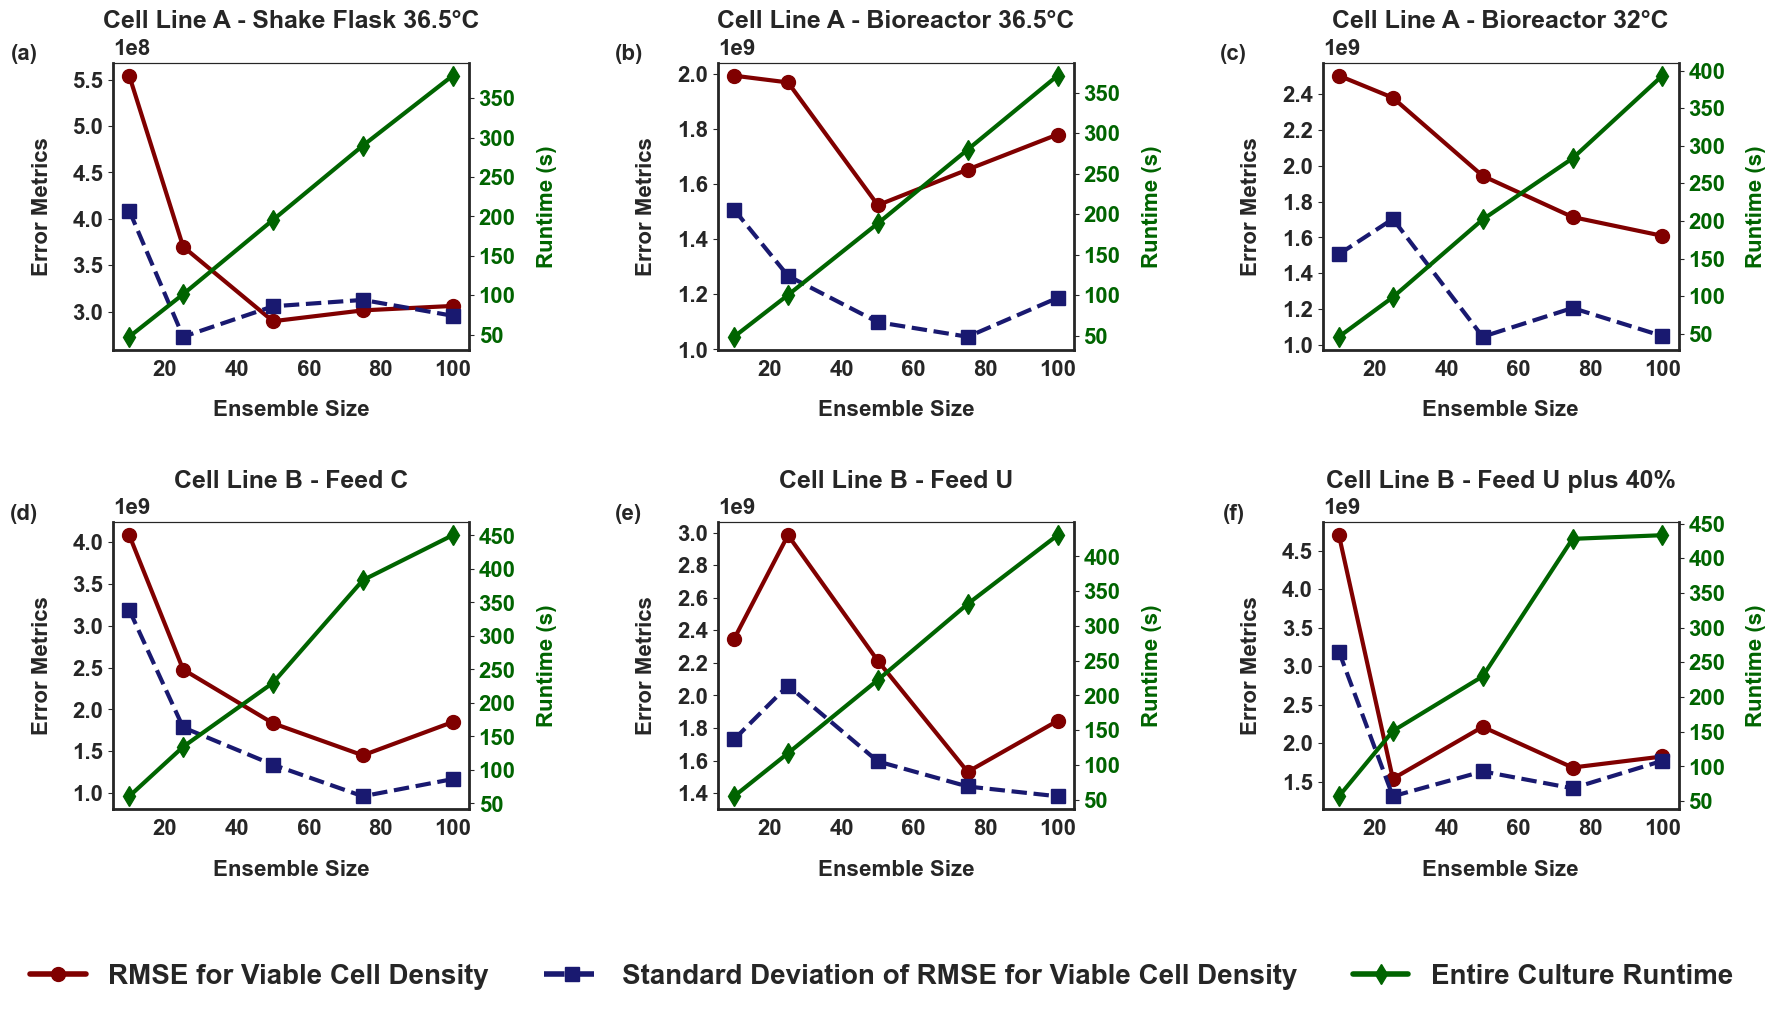

In [23]:
# Example usage:
#datasets_to_include = ['CHO_GS46_F_C_Inv']
datasets_to_include = ['CHO_T127_flask_PMJ', 'CHO_T127_SNS_36.5', 'CHO_T127_SNS_32', 'CHO_GS46_F_C_Inv', 'CHO_GS46_F_all', 'CHO_GS46_F_all_pl40']
#datasets_to_include = [ 'CHO_GS46_F_all_pl40']
custom_titles = {
    'CHO_T127_flask_PMJ' : 'Cell Line A - Shake Flask 36.5°C',
    'CHO_T127_SNS_36.5': 'Cell Line A - Bioreactor 36.5°C',
    'CHO_T127_SNS_32': 'Cell Line A - Bioreactor 32°C',
    'CHO_GS46_F_C_Inv': 'Cell Line B - Feed C',
    'CHO_GS46_F_all': 'Cell Line B - Feed U',
    'CHO_GS46_F_all_pl40': 'Cell Line B - Feed U plus 40%'
}
exclude_ensemble_sizes = []

plot_rmse_variance_and_computation_time_all(rmse_results, computation_times, 
                                          datasets_to_include, 
                                          exclude_ensemble_sizes=exclude_ensemble_sizes, 
                                          custom_titles=custom_titles,
                                          save_path="ensemble_tuning-withPMJ.png")

In [24]:
def plot_best_ensemble_simulation(simulation_results, 
                             datasets, 
                             ensemble_tuning, 
                             dataset_ensemble_sizes, 
                             axis_name):
    """
    Plots the simulation results for specific datasets, each with a specified ensemble size.

    Parameters:
        simulation_results (dict): Dictionary containing model simulation results.
            Structure: {dataset_name: {"full_simulation": numpy_array, ...}, ...}
        datasets (dict): Dictionary containing experimental measurements.
            Structure: {dataset_name: {"exp_meas": dataframe, ...}, ...}
        ensemble_tuning (dict): Dictionary containing EnKF simulation results.
            Structure: {dataset_name: {ensemble_size: numpy_array_of_states, ...}, ...}
        dataset_ensemble_sizes (dict): Mapping from dataset name to desired ensemble size.
            Example: {"datasetA": 25, "datasetB": 50, ...}
        axis_name (list): List of axis labels (one per state).
    """
    sns.set(style="white", context="talk")  # Use Seaborn style for presentation

    # Loop only over the datasets and ensemble sizes the user specifies
    for dataset_name, ensemble_size in dataset_ensemble_sizes.items():
        if dataset_name not in simulation_results:
            print(f"⚠️ Warning: '{dataset_name}' not found in simulation_results. Skipping...")
            continue
        
        print(f"📊 Plotting results for {dataset_name} (Ensemble Size: {ensemble_size})...")

        # Extract model simulation results
        set_model = simulation_results[dataset_name]["full_simulation"]

        # Generate time vector based on simulation length
        T_model = np.linspace(0, len(set_model) * 0.01, len(set_model))

        # Extract experimental data
        exp_meas = datasets[dataset_name]["exp_meas"]
        real_obs_time = exp_meas["Time (hours)"].values
        real_obs = exp_meas.iloc[:, 1:9].values  # All columns except "Time (hours)"

        # Extract EnKF simulation results
        if (dataset_name in ensemble_tuning and 
            ensemble_size in ensemble_tuning[dataset_name]):
            set_EnKF = ensemble_tuning[dataset_name][ensemble_size]
        else:
            print(f"⚠️ Warning: No EnKF results found for {dataset_name} with ensemble size {ensemble_size}. Skipping...")
            continue

        num_states = set_EnKF.shape[1]

        for i in range(num_states):
            plt.figure(figsize=(8, 6))

            # Plot reference model (Kotidis2019) trajectory
            sns.lineplot(x=T_model, y=set_model[:, i],
                         color='maroon', label='Kotidis 2019 Model', linewidth=4)

            # Plot experimental measurements
            sns.scatterplot(x=real_obs_time, y=real_obs[:, i],
                            color='orange', label='Experimental Measurements', s=100)

            # Plot EnKF simulation (ensemble mean)
            sns.lineplot(x=T_model, y=set_EnKF[:, i],
                         color='black', label='EnKF', linewidth=4)

            plt.xlabel('Time (hours)')
            plt.ylabel(axis_name[i])
            plt.title(f"{dataset_name} - {axis_name[i]} (Ensemble Size: {ensemble_size})")
            plt.legend(loc='best', frameon=False)
            plt.tight_layout()

            # (Optional) Save plot as high-resolution png
            # plt.savefig(f'plot_{dataset_name}_ensemble_{ensemble_size}_state_{i}.png', 
            #             format='png', dpi=300, bbox_inches='tight')
            plt.show()

# Example usage:
best_ensemble_sizes = {
     "CHO_T127_SNS_36.5": 50,
    "CHO_T127_SNS_32": 50,
    "CHO_GS46_F_C_Inv": 75,
    "CHO_GS46_F_all": 75,
    "CHO_GS46_F_all_pl40": 75,
    "CHO_T127_flask_PMJ": 50
}
#plot_best_ensemble_simulation(simulation_results, datasets, ensemble_tuning, best_ensemble_sizes, axis_names)

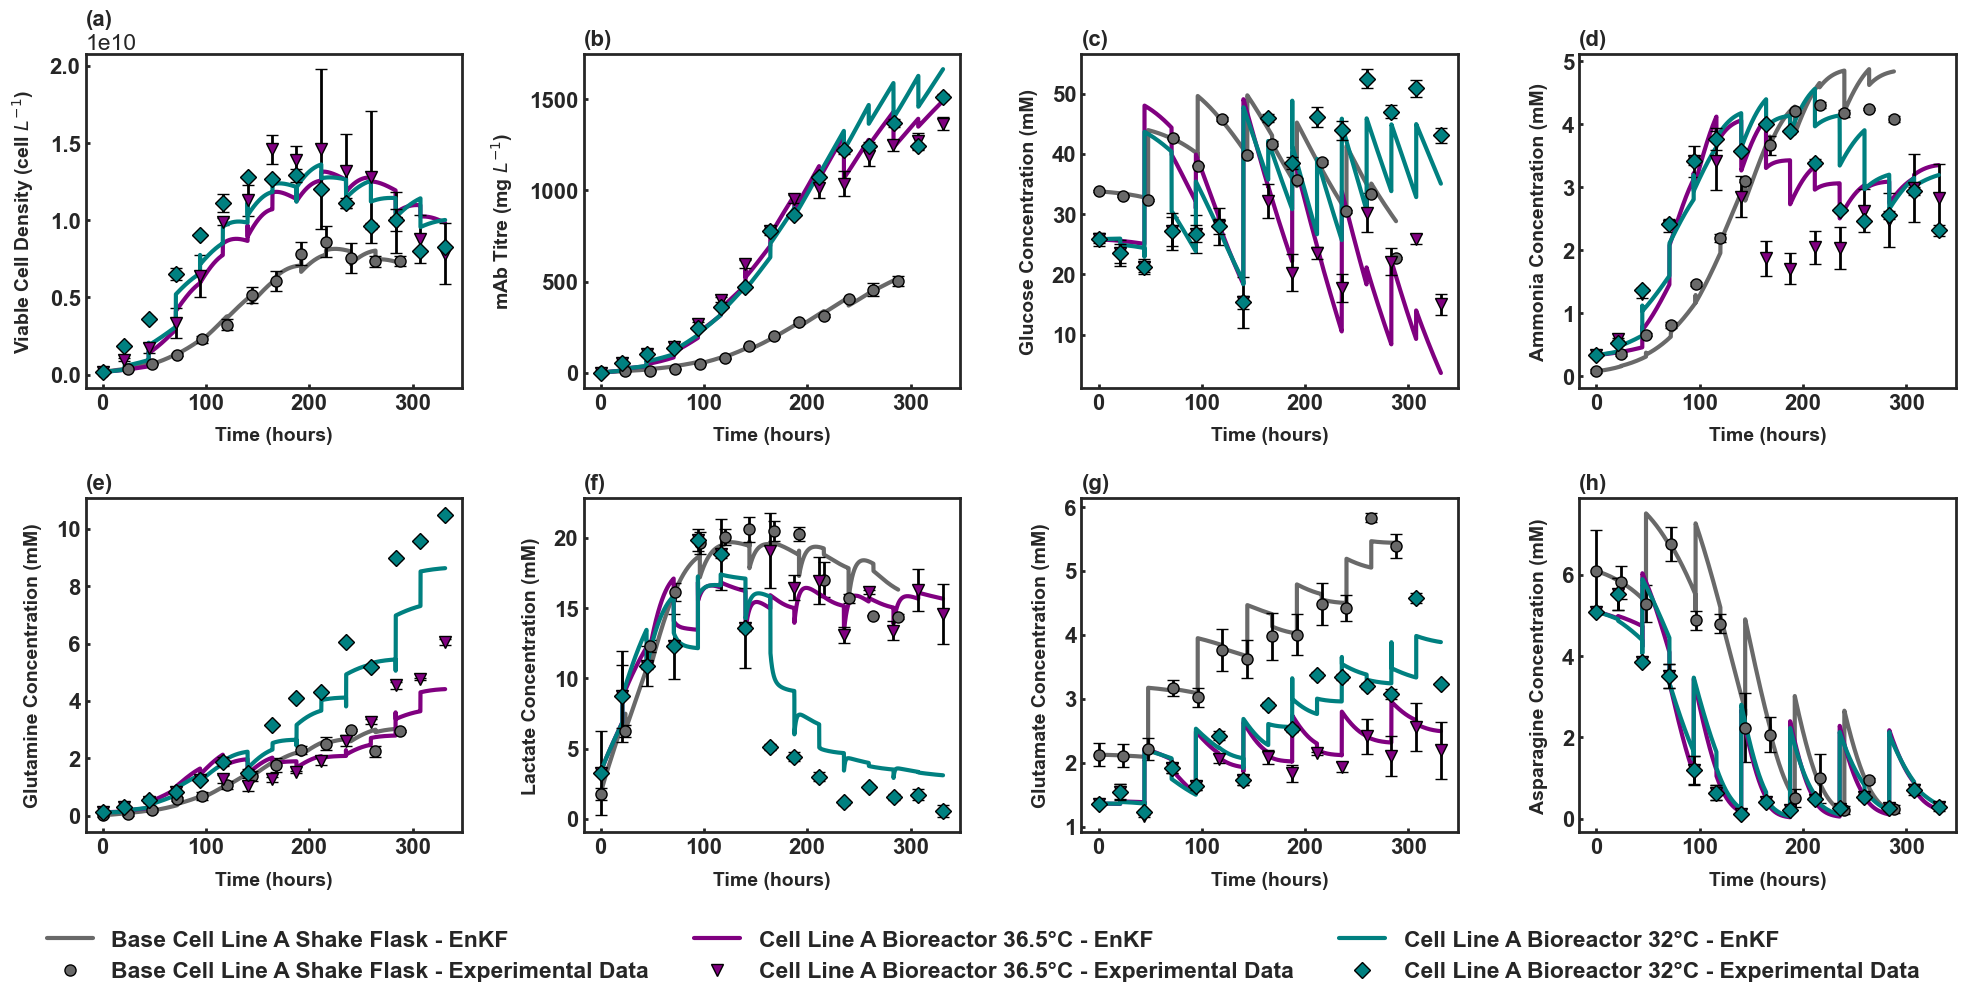

In [25]:
def overlay_T127_subplots_with_errorbars(simulation_results, datasets, ensemble_tuning, 
                                          dataset_ensemble_sizes, state_names, axis_name, 
                                          save_path="T127_overlay_errorbars.png"):
    """
    Overlays the three T127 feeding strategies in one set of subplots per state,
    adding experimental error bars from biological triplicates, using different markers per dataset.
    """

    sns.set(style="white", context="talk")
    dt = 0.01  # Time step

    T127_datasets = ["CHO_T127_flask_PMJ", "CHO_T127_SNS_36.5", "CHO_T127_SNS_32"]

    colours = {
        "CHO_T127_flask_PMJ": "dimgray",  
        "CHO_T127_SNS_36.5": "purple",     
        "CHO_T127_SNS_32":  "teal"    
    }

    markers = {
        "CHO_T127_flask_PMJ": "o",   # Circle
        "CHO_T127_SNS_36.5": "v",    # Triangle
        "CHO_T127_SNS_32": "D"       # Diamond
    }

    reference_dataset = T127_datasets[0]
    num_states = simulation_results[reference_dataset]["full_simulation"].shape[1]

    # 2x4 subplot grid
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

    for i in range(num_states):
        ax = axes[i]
        ax.set_title(subplot_labels[i], fontsize=16, fontweight='bold', loc='left')

        for dataset_name in T127_datasets:
            ensemble_size = dataset_ensemble_sizes[dataset_name]
            color = colours[dataset_name]
            marker = markers[dataset_name]

            set_EnKF = ensemble_tuning[dataset_name][ensemble_size]
            exp_meas = datasets[dataset_name]["exp_meas"]

            T_model = np.linspace(0, len(set_EnKF) * dt, len(set_EnKF))
            real_obs_time = exp_meas["Time (hours)"].values

            # Plot EnKF (solid line)
            ax.plot(T_model, set_EnKF[:, i], linestyle='-', linewidth=3, color=color)

            # Plot experimental data with error bars
            state = state_names[i]
            if f"{state}_std" in exp_meas.columns:
                std_dev = exp_meas[f"{state}_std"].values
                ax.errorbar(real_obs_time, exp_meas[state].values, yerr=std_dev,
                            fmt=marker, color=color, ecolor='black', elinewidth=2,
                            capsize=4, markersize=8, markeredgecolor='black')
            else:
                ax.scatter(real_obs_time, exp_meas[state].values, 
                           color=color, s=80, edgecolor='black', marker=marker)

        # Axis formatting
        ax.set_xlabel('Time (hours)', fontsize=14, fontweight='bold', labelpad=10)
        ax.set_ylabel(axis_name[i], fontsize=14, fontweight='bold', labelpad=10)

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(16)
            label.set_fontweight('bold')

        ax.tick_params(axis='x', which='both', bottom=True, top=False, direction='in', length=3, width=2)
        ax.tick_params(axis='y', which='both', left=True, right=False, direction='in', length=3, width=2)

        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)

    # Remove empty subplots if fewer than 8 states
    for j in range(num_states, len(axes)):
        fig.delaxes(axes[j])

    # Legend
    legend_elements = [
        Line2D([0], [0], color=colours["CHO_T127_flask_PMJ"], lw=3, label="Base Cell Line A Shake Flask - EnKF"),
        Line2D([0], [0], marker=markers["CHO_T127_flask_PMJ"], color=colours["CHO_T127_flask_PMJ"], markersize=8, linestyle='None',
               markeredgecolor='black', label="Base Cell Line A Shake Flask - Experimental Data"),

        Line2D([0], [0], color=colours["CHO_T127_SNS_36.5"], lw=3, label="Cell Line A Bioreactor 36.5°C - EnKF"),
        Line2D([0], [0], marker=markers["CHO_T127_SNS_36.5"], color=colours["CHO_T127_SNS_36.5"], markersize=8, linestyle='None',
               markeredgecolor='black', label="Cell Line A Bioreactor 36.5°C - Experimental Data"),

        Line2D([0], [0], color=colours["CHO_T127_SNS_32"], lw=3, label="Cell Line A Bioreactor 32°C - EnKF"),
        Line2D([0], [0], marker=markers["CHO_T127_SNS_32"], color=colours["CHO_T127_SNS_32"], markersize=8, linestyle='None',
               markeredgecolor='black', label="Cell Line A Bioreactor 32°C - Experimental Data")
    ]

    fig.legend(handles=legend_elements,
               loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02),
               fontsize=14, frameon=False, prop={'weight': 'bold'})

    fig.tight_layout(rect=[0, 0.08, 1, 1])
    plt.subplots_adjust(bottom=0.15)

    plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
    plt.show()




best_ensemble_sizes = {
    "CHO_T127_flask_PMJ": 50,
    "CHO_T127_SNS_36.5": 50,
    "CHO_T127_SNS_32": 50
}

overlay_T127_subplots_with_errorbars(simulation_results, datasets, ensemble_tuning, 
                                     best_ensemble_sizes, state_names, axis_names)

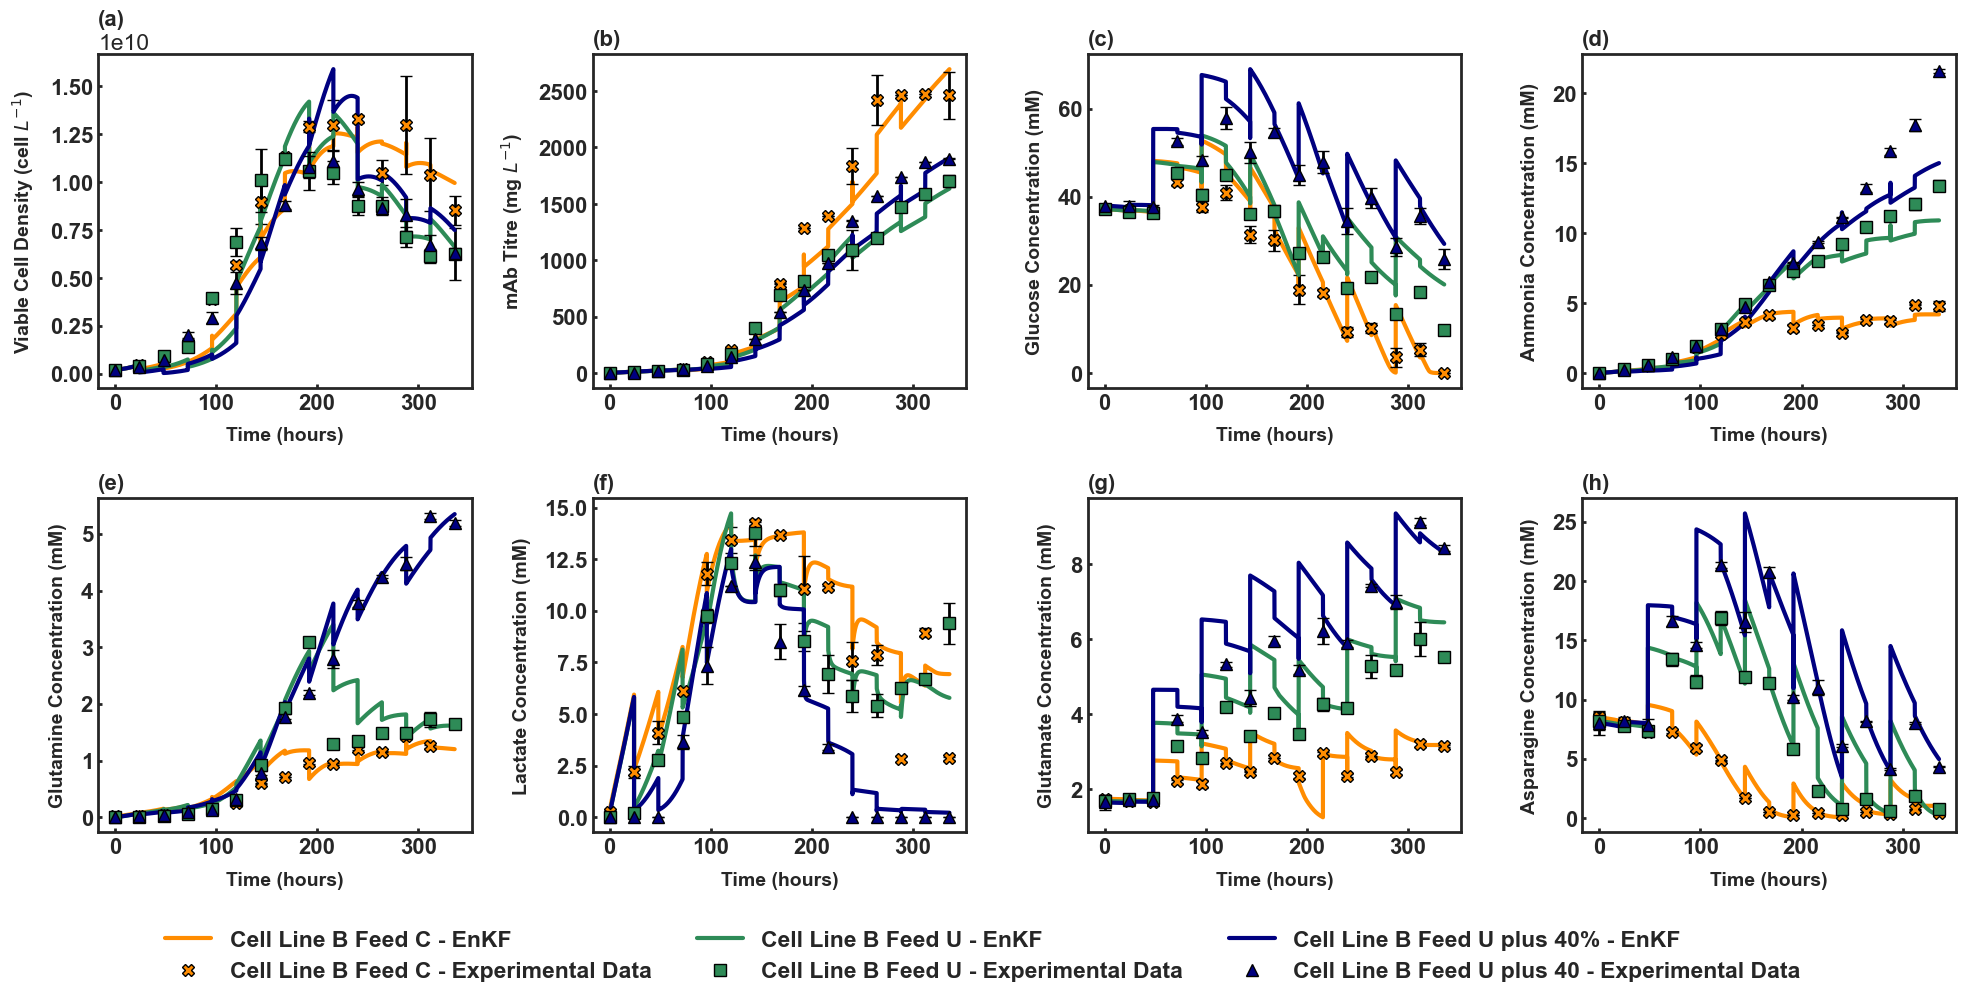

In [26]:
def overlay_gs46_subplots_with_errorbars(simulation_results, datasets, ensemble_tuning, 
                                          dataset_ensemble_sizes, state_names, axis_name, 
                                          save_path="gs46_overlay_errorbars.png"):
    """
    Overlays the three GS46 feeding strategies in one set of subplots per state,
    adding experimental error bars from biological triplicates, using distinct markers for each dataset.
    """

    sns.set(style="white", context="talk")
    dt = 0.01  # Time step

    gs46_datasets = ["CHO_GS46_F_C_Inv", "CHO_GS46_F_all", "CHO_GS46_F_all_pl40"]

    colours = {
        "CHO_GS46_F_C_Inv": "darkorange",
        "CHO_GS46_F_all": "seagreen",
        "CHO_GS46_F_all_pl40": "navy"
    }

    markers = {
        "CHO_GS46_F_C_Inv": "X",   # Bold Cross
        "CHO_GS46_F_all": "s",     # Square
        "CHO_GS46_F_all_pl40": "^" # Triangle Up
    }

    reference_dataset = gs46_datasets[0]
    num_states = simulation_results[reference_dataset]["full_simulation"].shape[1]

    # 2x4 subplot grid
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

    for i in range(num_states):
        ax = axes[i]
        ax.set_title(subplot_labels[i], fontsize=16, fontweight='bold', loc='left')

        for dataset_name in gs46_datasets:
            ensemble_size = dataset_ensemble_sizes[dataset_name]
            color = colours[dataset_name]
            marker = markers[dataset_name]

            set_EnKF = ensemble_tuning[dataset_name][ensemble_size]
            exp_meas = datasets[dataset_name]["exp_meas"]

            T_model = np.linspace(0, len(set_EnKF) * dt, len(set_EnKF))
            real_obs_time = exp_meas["Time (hours)"].values

            # Plot EnKF (solid line)
            ax.plot(T_model, set_EnKF[:, i], linestyle='-', linewidth=3, color=color)

            # Plot experimental data with error bars if available
            state = state_names[i]
            if f"{state}_std" in exp_meas.columns:
                std_dev = exp_meas[f"{state}_std"].values
                ax.errorbar(real_obs_time, exp_meas[state].values, yerr=std_dev,
                            fmt=marker, color=color, ecolor='black', elinewidth=2,
                            capsize=4, markersize=8, markeredgecolor='black')
            else:
                ax.scatter(real_obs_time, exp_meas[state].values, 
                           color=color, s=80, marker=marker, edgecolor='black')

        # Axis formatting
        ax.set_xlabel('Time (hours)', fontsize=14, fontweight='bold', labelpad=10)
        ax.set_ylabel(axis_name[i], fontsize=14, fontweight='bold', labelpad=10)

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(16)
            label.set_fontweight('bold')

        ax.tick_params(axis='x', which='both', bottom=True, top=False, direction='in', length=3, width=2)
        ax.tick_params(axis='y', which='both', left=True, right=False, direction='in', length=3, width=2)

        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)

    # Remove empty subplots if fewer than 8 states
    for j in range(num_states, len(axes)):
        fig.delaxes(axes[j])

    # Legend
    legend_elements = [
        Line2D([0], [0], color=colours["CHO_GS46_F_C_Inv"], lw=3, label="Cell Line B Feed C - EnKF"),
        Line2D([0], [0], marker='X', color=colours["CHO_GS46_F_C_Inv"], markersize=8, linestyle='None',
               markeredgecolor='black', label="Cell Line B Feed C - Experimental Data"),

        Line2D([0], [0], color=colours["CHO_GS46_F_all"], lw=3, label="Cell Line B Feed U - EnKF"),
        Line2D([0], [0], marker='s', color=colours["CHO_GS46_F_all"], markersize=8, linestyle='None',
               markeredgecolor='black', label="Cell Line B Feed U - Experimental Data"),

        Line2D([0], [0], color=colours["CHO_GS46_F_all_pl40"], lw=3, label="Cell Line B Feed U plus 40% - EnKF"),
        Line2D([0], [0], marker='^', color=colours["CHO_GS46_F_all_pl40"], markersize=8, linestyle='None',
               markeredgecolor='black', label="Cell Line B Feed U plus 40 - Experimental Data")
    ]

    fig.legend(handles=legend_elements,
               loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02),
               fontsize=14, frameon=False, prop={'weight': 'bold'})

    fig.tight_layout(rect=[0, 0.08, 1, 1])
    plt.subplots_adjust(bottom=0.15)

    plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
    plt.show()



best_ensemble_sizes = {
    "CHO_GS46_F_C_Inv": 75,
    "CHO_GS46_F_all": 75,
    "CHO_GS46_F_all_pl40": 75
}

overlay_gs46_subplots_with_errorbars(simulation_results, datasets, ensemble_tuning, 
                                     best_ensemble_sizes, state_names, axis_names)


## Long term prediction with the best ensemble size

In [29]:
def enkf_long_pred_best_ensemble_size(datasets, dataset_noise_variances, volume_results, dataset_ensemble_sizes):
    """
    Runs the long-term EnKF prediction process for multiple datasets using a manually specified ensemble size per dataset. 
    This ensemble size should be derived from the previous tuning simulation.
    
    Returns:
        long_term_forecasts_best (dict): Long-term forecast records for each dataset.
    """
    import time  # needed for timing
    
    PX_records_best = {}
    para_records_best = {}
    X_forecast_for_parameters_records_best = {}
    X_forecast_for_states_records_best = {}
    X_posterior_records_best = {}
    Z_best = {}
    simulation_trajectories_best = {}
    long_term_forecasts_best = {}  # ✅ Store forecasts for all datasets

    decimal_places = 2

    for dataset_name, data in datasets.items():
        print(f"Processing dataset: {dataset_name}")
        
        # Extract schedule values and volume
        Fin = data["schedule"]["Fin"].values
        Fout = data["schedule"]["Fout"].values
        Fin_glc = data["schedule"]["Fin_glc"].values
        V = volume_results[dataset_name]  # Precomputed volume
        
        exp_meas = data["exp_meas"]
        real_obs_time = exp_meas["Time (hours)"].values
        state_init = exp_meas.iloc[0][['Xv', 'mAb', 'Glc', 'Amm', 'Gln', 'Lac', 'Glu', 'Asn']].values
        feed = data["feed"].set_index("Metabolite")["Concentration (mM)"].to_dict()
        
        # Define simulation time steps
        time_steps_A = [i * 0.01 for i in range(len(Fin))]
        time_steps_B = real_obs_time
        time_steps_A = [round(step, decimal_places) for step in time_steps_A]
        time_steps_B = [round(step, decimal_places) for step in time_steps_B]
        
        # Retrieve desired ensemble size for this dataset
        ensemble_size = dataset_ensemble_sizes.get(dataset_name, 22)
        print(f"Running EnKF with ensemble size: {ensemble_size} for {dataset_name}")
        start_time = time.time()
        
        # Retrieve tuning parameters (assumed defined externally)
        kQ = kQ_dict[dataset_name]
        kR = kR_dict[dataset_name]
        
        Q = kQ * np.diag(list(dataset_noise_variances[dataset_name]["process_var"].values()))
        R = kR * np.diag(list(dataset_noise_variances[dataset_name]["obs_var"].values()))
        H = np.eye(len(state_init))
        real_obs = data["exp_meas"].iloc[:, 1:9].values  # Adjust if necessary
        dt_kf = 0.01
        state_num = len(state_init)
        
        # Instantiate the EnKF object using a new object name
        enkf_long_pred = EnKF_ParameterEstimation(dataset_name, datasets, dataset_noise_variances, dt_model=dt_kf)
        
        # Initialize EnKF internal variables
        enkf_long_pred.PX = []
        enkf_long_pred.PX_records = []
        enkf_long_pred.para = mean_parameters.copy()  # defined externally
        enkf_long_pred.para_records = [mean_parameters.copy()]
        enkf_long_pred.x = state_init.copy()
        enkf_long_pred.Q = Q.copy()
        enkf_long_pred.H = H.copy()
        enkf_long_pred.R = R.copy()
        enkf_long_pred.z = exp_meas.iloc[:, 1:9].values
        enkf_long_pred.Z = []
        enkf_long_pred.fx = model_step  # defined externally
        enkf_long_pred.dt = dt_kf
        enkf_long_pred.num_x = state_num
        
        enkf_long_pred.X_forecast_for_parameters_records = []
        enkf_long_pred.X_forecast_for_states_records = []
        enkf_long_pred.X_posterior_records = []
        
        # Create ensembles and generate noisy observations
        set_EnKF = [state_init.copy()]
        enkf_long_pred.create_parameters_ensemble(ensemble_size, parameters_ensemble_covariance)  # defined externally
        enkf_long_pred.create_states_ensemble(ensemble_size)
        enkf_long_pred.create_noisy_observations(ensemble_size)
        enkf_long_pred.PX_records.append(enkf_long_pred.PX)
        
        long_term_forecasts = []  # ✅ Store forecasts per dataset

        # Main simulation loop
        for idx_A, step_A in enumerate(tqdm(time_steps_A, desc=f"Processing {dataset_name}", unit="step")):
            if step_A in time_steps_B:
                idx_B = np.searchsorted(time_steps_B, step_A)
                print(f"Updating parameters at time {step_A} (Day {idx_B})")
                enkf_long_pred.forecast_for_parameters((Fin[idx_A], Fout[idx_A], Fin_glc[idx_A], V[idx_A], feed))
                enkf_long_pred.parameters_update(idx_B)
                #enkf_long_pred.PX_records.append(enkf_long_pred.PX)
            
            enkf_long_pred.forecast_for_states((Fin[idx_A], Fout[idx_A], Fin_glc[idx_A], V[idx_A], feed))
            
            for idx_B, step_B in enumerate(time_steps_B):
                if step_A == step_B:
                    enkf_long_pred.states_update(idx_B)
            
            set_EnKF.append(enkf_long_pred.x.copy())
            
            if step_A in time_steps_B:
                current_state = enkf_long_pred.x.copy()
                current_para = {key: np.mean([d[key] for d in enkf_long_pred.PX]) for key in enkf_long_pred.PX[0].keys()}
                forecast_trajectory = [current_state.copy()]
                # Adapted controls: include Fin_glc and feed as in forecast_for_states
                for forecast_idx in range(idx_A + 1, len(time_steps_A)):
                    controls = (Fin[forecast_idx], Fout[forecast_idx], Fin_glc[forecast_idx], V[forecast_idx], feed)
                    current_state = enkf_long_pred.forecast_long(controls, current_state, current_para)
                    forecast_trajectory.append(current_state.copy())
                long_term_forecasts.append(np.array(forecast_trajectory))
        
        set_EnKF = np.array(set_EnKF)
        simulation_trajectories_best[dataset_name] = set_EnKF
        
        PX_records_best[dataset_name] = {ensemble_size: enkf_long_pred.PX_records}
        para_records_best[dataset_name] = {ensemble_size: enkf_long_pred.para_records}
        X_forecast_for_parameters_records_best[dataset_name] = {ensemble_size: enkf_long_pred.X_forecast_for_parameters_records}
        X_forecast_for_states_records_best[dataset_name] = {ensemble_size: enkf_long_pred.X_forecast_for_states_records}
        X_posterior_records_best[dataset_name] = {ensemble_size: enkf_long_pred.X_posterior_records}
        Z_best[dataset_name] = {ensemble_size: enkf_long_pred.Z}
        
        long_term_forecasts_best[dataset_name] = long_term_forecasts  # ✅ Store forecasts

    return (PX_records_best, para_records_best, 
            X_forecast_for_parameters_records_best, 
            X_forecast_for_states_records_best, 
            X_posterior_records_best, Z_best, 
            simulation_trajectories_best, long_term_forecasts_best)  # ✅ Return all forecasts


# Example usage:
dataset_ensemble_sizes = {
    "CHO_T127_SNS_36.5": 50,
    "CHO_T127_SNS_32": 50,
    "CHO_GS46_F_C_Inv": 75,
    "CHO_GS46_F_all": 75,
    "CHO_GS46_F_all_pl40": 75, 
    "CHO_T127_flask_PMJ" : 50
}


In [30]:

# Run simulation
long_term_pred_records = enkf_long_pred_best_ensemble_size(datasets, dataset_noise_variances, volume_results, dataset_ensemble_sizes)

# Unpacking the results
(PX_records_best, para_records_best, 
 X_forecast_for_parameters_records_best, 
 X_forecast_for_states_records_best, 
 X_posterior_records_best, Z_best, simulation_trajectories_best, long_term_forecasts_best) = long_term_pred_records

Processing dataset: CHO_T127_flask_PMJ
Running EnKF with ensemble size: 50 for CHO_T127_flask_PMJ


Processing CHO_T127_flask_PMJ:   0%|                                                       | 0/28800 [00:00<?, ?step/s]

Updating parameters at time 0.0 (Day 0)


Processing CHO_T127_flask_PMJ:   8%|███▌                                       | 2391/28800 [00:24<03:02, 144.81step/s]

Updating parameters at time 24.0 (Day 1)


...

Processing CHO_GS46_F_all_pl40:  86%|███████████████████████████████████▉      | 28798/33600 [06:02<01:36, 49.91step/s]

Updating parameters at time 288.0 (Day 12)


Processing CHO_GS46_F_all_pl40:  93%|███████████████████████████████████████   | 31200/33600 [06:47<00:50, 47.27step/s]

Updating parameters at time 312.0 (Day 13)


Processing CHO_GS46_F_all_pl40: 100%|██████████████████████████████████████████| 33600/33600 [07:59<00:00, 70.05step/s]


In [37]:
# Save all required datasets
save_pkl(PX_records_best, 'PX_records_best.pkl')
save_pkl(para_records_best, 'para_records_best.pkl')
save_pkl(X_forecast_for_parameters_records_best, 'X_forecast_for_parameters_records_best.pkl')
save_pkl(X_forecast_for_states_records_best, 'X_forecast_for_states_records_best.pkl')
save_pkl(X_posterior_records_best, 'X_posterior_records_best.pkl')
save_pkl(Z_best, 'Z_best.pkl')
save_pkl(simulation_trajectories_best, 'simulation_trajectories_best.pkl')
save_pkl(long_term_forecasts_best, 'long_term_forecasts_best.pkl')

print("All best datasets saved successfully!")

File saved at: retune2nov\PX_records_best.pkl
File saved at: retune2nov\para_records_best.pkl
File saved at: retune2nov\X_forecast_for_parameters_records_best.pkl
File saved at: retune2nov\X_forecast_for_states_records_best.pkl
File saved at: retune2nov\X_posterior_records_best.pkl
File saved at: retune2nov\Z_best.pkl
File saved at: retune2nov\simulation_trajectories_best.pkl
File saved at: retune2nov\long_term_forecasts_best.pkl
All best datasets saved successfully!


In [31]:
# Load all datasets
PX_records_best = load_pkl('PX_records_best.pkl')
para_records_best = load_pkl('para_records_best.pkl')
X_forecast_for_parameters_records_best = load_pkl('X_forecast_for_parameters_records_best.pkl')
X_forecast_for_states_records_best = load_pkl('X_forecast_for_states_records_best.pkl')
X_posterior_records_best = load_pkl('X_posterior_records_best.pkl')
Z_best = load_pkl('Z_best.pkl')
simulation_trajectories_best = load_pkl('simulation_trajectories_best.pkl')
long_term_forecasts_best = load_pkl('long_term_forecasts_best.pkl')

print("🎯 All best datasets successfully loaded!")

🎯 All best datasets successfully loaded!


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Define dataset-specific colours
dataset_colours = {
    # GS46
    "CHO_GS46_F_C_Inv": "darkorange",
    "CHO_GS46_F_all": "seagreen",
    "CHO_GS46_F_all_pl40": "navy",
    # T127
    "CHO_T127_flask_PMJ": "dimgrey",    # Firebrick
    "CHO_T127_SNS_36.5": "purple" ,       # Dark Cyan
     "CHO_T127_SNS_32":  "teal"  # Midnight Blue
}


# Define dataset-specific markers
dataset_markers = {
    # GS46
    "CHO_GS46_F_C_Inv": "X",     # Bold Cross
    "CHO_GS46_F_all": "s",       # Square
    "CHO_GS46_F_all_pl40": "^",  # Triangle Up
    # T127
    "CHO_T127_flask_PMJ": "o",   # Circle
    "CHO_T127_SNS_36.5": "v",    # Triangle Down
    "CHO_T127_SNS_32": "D"       # Diamond
}

def plot_longterm_pred_ensemble_simulation_errorbar(simulation_results, datasets, 
                                                    ensemble_tuning, dataset_ensemble_sizes, 
                                                    long_term_forecasts_all, axis_name, state_names,
                                                    selected_forecast_indices=None, 
                                                    save_path="long_term_pred.png",
                                                    forecast_linestyles=None):
    """
    Plots simulation results, experimental data (with error bars), EnKF simulation, and forecasts.
    Each dataset uses fixed colour and marker for EnKF and forecasts. Kotidis 2019 model is black.
    """

    sns.set(style="white", context="talk")
    dt = 0.01

    # Default dash styles for forecast days
    day_dash_mapping = {7: "--",9: "-.", 12: ":"}

    if forecast_linestyles is not None:
        unique_days = [6, 8, 10, 12]
        day_dash_mapping = {day: forecast_linestyles[i % len(forecast_linestyles)] for i, day in enumerate(unique_days)}

    for dataset_name, ensemble_size in dataset_ensemble_sizes.items():
        if dataset_name not in simulation_results:
            print(f"⚠️ Warning: '{dataset_name}' not found in simulation_results. Skipping...")
            continue

        print(f"📊 Plotting results for {dataset_name} (Ensemble Size: {ensemble_size})...")

        set_model = simulation_results[dataset_name]["full_simulation"]
        T_model = np.linspace(0, len(set_model) * dt, len(set_model))

        exp_meas = datasets[dataset_name]["exp_meas"]
        real_obs_time = exp_meas["Time (hours)"].values

        if dataset_name in ensemble_tuning and ensemble_size in ensemble_tuning[dataset_name]:
            set_EnKF = ensemble_tuning[dataset_name][ensemble_size]
        else:
            print(f"⚠️ Warning: No EnKF results found for {dataset_name} with ensemble size {ensemble_size}. Skipping...")
            continue

        num_states = set_EnKF.shape[1]
        fig, axes = plt.subplots(3, 3, figsize=(16, 14))
        axes = axes.flatten()

        # Prepare forecast legend
        forecast_legend_elements = []
        forecasts = None
        sorted_forecast_indices = []

        if dataset_name in long_term_forecasts_all:
            forecasts = long_term_forecasts_all[dataset_name]
            if selected_forecast_indices is not None and dataset_name in selected_forecast_indices:
                sorted_forecast_indices = sorted(selected_forecast_indices[dataset_name])
            else:
                sorted_forecast_indices = list(range(len(forecasts)))

            for j in sorted_forecast_indices:
                dash_style = day_dash_mapping.get(j, "--")
                forecast_legend_elements.append(
                    Line2D([0], [0], color=dataset_colours[dataset_name],
                           lw=2, linestyle=dash_style,
                           label=f'Prediction from Day {j}')
                )

        subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)']

        for i in range(num_states):
            ax = axes[i]
            ax.set_title(subplot_labels[i], fontsize=16, fontweight='bold', loc='left')

            # Kotidis 2019 model (always red in your current version)
            sns.lineplot(x=T_model, y=set_model[:, i], color='red', linewidth=3, ax=ax)

            # EnKF (dataset-specific colour)
            sns.lineplot(x=T_model, y=set_EnKF[:, i], color=dataset_colours[dataset_name], linewidth=3, ax=ax)

            # Forecasts (same colour, different dash)
            if forecasts is not None:
                for j in sorted_forecast_indices:
                    forecast = forecasts[j]
                    update_idx = len(T_model) - forecast.shape[0]
                    if update_idx + forecast.shape[0] != len(T_model):
                        continue
                    
                    full_forecast = np.concatenate((set_EnKF[:update_idx, i], forecast[:, i]))
                    dash_style = day_dash_mapping.get(j, "--")
                    ax.plot(T_model, full_forecast, 
                            linestyle=dash_style, 
                            linewidth=3, 
                            color=dataset_colours[dataset_name])

            # Experimental data with dataset-specific markers and matching fill
            state_col = state_names[i]
            label_col = axis_name[i]

            if f"{state_col}_std" in exp_meas.columns:
                std_dev = exp_meas[f"{state_col}_std"].values
                ax.errorbar(real_obs_time, exp_meas[state_col].values, yerr=std_dev,
                            fmt=dataset_markers[dataset_name],
                            markerfacecolor=dataset_colours[dataset_name],
                            markeredgecolor='black',
                            ecolor='black', elinewidth=2,
                            capsize=3, markersize=8,
                            label="Experimental" if i == 0 else None)
            else:
                ax.scatter(real_obs_time, exp_meas[state_col].values, 
                           s=80, color=dataset_colours[dataset_name],
                           edgecolor='black', marker=dataset_markers[dataset_name],
                           label="Experimental" if i == 0 else None)

            # Formatting
            ax.set_xlabel('Time (hours)', fontsize=14, fontweight='bold', labelpad=10)
            ax.set_ylabel(label_col, fontsize=14, fontweight='bold', labelpad=10)

            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontsize(16)
                label.set_fontweight('bold')

            ax.tick_params(axis='x', which='both', bottom=True, top=False, direction='in', length=3, width=2)
            ax.tick_params(axis='y', which='both', left=True, right=False, direction='in', length=3, width=2)

            ax.spines['top'].set_linewidth(2)
            ax.spines['right'].set_linewidth(2)
            ax.spines['left'].set_linewidth(2)
            ax.spines['bottom'].set_linewidth(2)

            if ax.get_legend() is not None:
                ax.get_legend().remove()

        # Remove unused subplots
        for j in range(num_states, len(axes)):
            fig.delaxes(axes[j])

        fig.tight_layout(rect=[0, 0, 1, 1])
        plt.subplots_adjust(bottom=0.12)

        # Static legend with markerfacecolor = dataset colour
        static_legend_elements = [
            Line2D([0], [0], color='red', lw=3, label='Kotidis 2019 Model'),
            Line2D([0], [0], marker=dataset_markers[dataset_name],
                   markerfacecolor=dataset_colours[dataset_name],
                   markeredgecolor='black', markersize=8, linestyle='None',
                   label='Experimental Measurement'),
            Line2D([0], [0], color=dataset_colours[dataset_name], lw=3, label='EnKF Full Trajectory')
        ]

        leg1 = fig.legend(handles=static_legend_elements, loc='lower center',
                          ncol=3, bbox_to_anchor=(0.5, -0.01),
                          fontsize=14, frameon=False, prop={'weight': 'bold'})
        fig.add_artist(leg1)

        if forecast_legend_elements:
            leg2 = fig.legend(handles=forecast_legend_elements, loc='lower center',
                              ncol=len(forecast_legend_elements), bbox_to_anchor=(0.5, -0.06),
                              fontsize=14, frameon=False, prop={'weight': 'bold'})
            fig.add_artist(leg2)

        # Save figure
        dataset_save_path = save_path.replace(".png", f"_{dataset_name}.png")
        plt.savefig(dataset_save_path, format='png', dpi=300, bbox_inches='tight')
        plt.show()


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Define dataset-specific colours
dataset_colours = {
    # GS46
    "CHO_GS46_F_C_Inv": "darkorange",
    "CHO_GS46_F_all": "seagreen",
    "CHO_GS46_F_all_pl40": "navy",
    # T127
    "CHO_T127_flask_PMJ": "dimgrey",
    "CHO_T127_SNS_36.5": "purple",
    "CHO_T127_SNS_32": "teal"
}

# Define dataset-specific markers
dataset_markers = {
    # GS46
    "CHO_GS46_F_C_Inv": "X",     # Bold Cross
    "CHO_GS46_F_all": "s",       # Square
    "CHO_GS46_F_all_pl40": "^",  # Triangle Up
    # T127
    "CHO_T127_flask_PMJ": "o",   # Circle
    "CHO_T127_SNS_36.5": "v",    # Triangle Down
    "CHO_T127_SNS_32": "D"       # Diamond
}

def plot_longterm_pred_ensemble_simulation_errorbar(simulation_results, datasets, 
                                                    ensemble_tuning, dataset_ensemble_sizes, 
                                                    long_term_forecasts_all, axis_name, state_names,
                                                    selected_forecast_indices=None, 
                                                    save_path="long_term_pred.png",
                                                    forecast_linestyles=None):
    """
    Plots simulation results, experimental data (with error bars), EnKF simulation, and forecasts.
    Each dataset uses fixed colour and marker for EnKF and forecasts. Kotidis 2019 model is red.
    """

    sns.set(style="white", context="talk")
    dt = 0.01

    # Default dash styles for forecast days
    day_dash_mapping = {7: "--", 9: ".", 12: ":"}

    if forecast_linestyles is not None:
        unique_days = [6, 8, 10, 12]
        day_dash_mapping = {day: forecast_linestyles[i % len(forecast_linestyles)]
                            for i, day in enumerate(unique_days)}

    for dataset_name, ensemble_size in dataset_ensemble_sizes.items():
        if dataset_name not in simulation_results:
            print(f"⚠️ Warning: '{dataset_name}' not found in simulation_results. Skipping...")
            continue

        print(f"📊 Plotting results for {dataset_name} (Ensemble Size: {ensemble_size})...")

        set_model = simulation_results[dataset_name]["full_simulation"]
        T_model = np.linspace(0, len(set_model) * dt, len(set_model))

        exp_meas = datasets[dataset_name]["exp_meas"]
        real_obs_time = exp_meas["Time (hours)"].values

        if dataset_name in ensemble_tuning and ensemble_size in ensemble_tuning[dataset_name]:
            set_EnKF = ensemble_tuning[dataset_name][ensemble_size]
        else:
            print(f"⚠️ Warning: No EnKF results found for {dataset_name} with ensemble size {ensemble_size}. Skipping...")
            continue

        num_states = set_EnKF.shape[1]
        # Fixed 2x4 subplot grid for 8 states
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.flatten()

        subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

        # Prepare forecast legend
        forecast_legend_elements = []
        forecasts = None
        sorted_forecast_indices = []

        if dataset_name in long_term_forecasts_all:
            forecasts = long_term_forecasts_all[dataset_name]
            if selected_forecast_indices is not None and dataset_name in selected_forecast_indices:
                sorted_forecast_indices = sorted(selected_forecast_indices[dataset_name])
            else:
                sorted_forecast_indices = list(range(len(forecasts)))

            for j in sorted_forecast_indices:
                dash_style = day_dash_mapping.get(j, "--")
                forecast_legend_elements.append(
                    Line2D([0], [0], color=dataset_colours[dataset_name],
                           lw=2, linestyle=dash_style,
                           label=f'Prediction from Day {j}')
                )

        for i in range(num_states):
            ax = axes[i]
            ax.set_title(subplot_labels[i], fontsize=16, fontweight='bold', loc='left')

            # Kotidis 2019 model
            sns.lineplot(x=T_model, y=set_model[:, i], color='red', linewidth=3, ax=ax)

            # EnKF
            sns.lineplot(x=T_model, y=set_EnKF[:, i], color=dataset_colours[dataset_name], linewidth=3, ax=ax)

            # Forecasts
            if forecasts is not None:
                for j in sorted_forecast_indices:
                    forecast = forecasts[j]
                    update_idx = len(T_model) - forecast.shape[0]
                    if update_idx + forecast.shape[0] != len(T_model):
                        continue
                    full_forecast = np.concatenate((set_EnKF[:update_idx, i], forecast[:, i]))
                    dash_style = day_dash_mapping.get(j, "--")
                    ax.plot(T_model, full_forecast,
                            linestyle=dash_style,
                            linewidth=3,
                            color=dataset_colours[dataset_name])

            # Experimental data
            state_col = state_names[i]
            label_col = axis_name[i]
            if f"{state_col}_std" in exp_meas.columns:
                std_dev = exp_meas[f"{state_col}_std"].values
                ax.errorbar(real_obs_time, exp_meas[state_col].values, yerr=std_dev,
                            fmt=dataset_markers[dataset_name],
                            markerfacecolor=dataset_colours[dataset_name],
                            markeredgecolor='black',
                            ecolor='black', elinewidth=2,
                            capsize=3, markersize=8)
            else:
                ax.scatter(real_obs_time, exp_meas[state_col].values,
                           s=80, color=dataset_colours[dataset_name],
                           edgecolor='black', marker=dataset_markers[dataset_name])

            # Formatting
            ax.set_xlabel('Time (hours)', fontsize=14, fontweight='bold', labelpad=10)
            ax.set_ylabel(label_col, fontsize=14, fontweight='bold', labelpad=10)

            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontsize(16)
                label.set_fontweight('bold')

            ax.tick_params(axis='x', which='both', bottom=True, top=False, direction='in', length=3, width=2)
            ax.tick_params(axis='y', which='both', left=True, right=False, direction='in', length=3, width=2)

            ax.spines['top'].set_linewidth(2)
            ax.spines['right'].set_linewidth(2)
            ax.spines['left'].set_linewidth(2)
            ax.spines['bottom'].set_linewidth(2)

            if ax.get_legend() is not None:
                ax.get_legend().remove()

        fig.tight_layout(rect=[0, 0, 1, 1])
        plt.subplots_adjust(bottom=0.12)

        # Static legend
        static_legend_elements = [
            Line2D([0], [0], color='red', lw=3, label='Kotidis 2019 Model'),
            Line2D([0], [0], marker=dataset_markers[dataset_name],
                   markerfacecolor=dataset_colours[dataset_name],
                   markeredgecolor='black', markersize=8, linestyle='None',
                   label='Experimental Data'),
            Line2D([0], [0], color=dataset_colours[dataset_name], lw=3, label='EnKF Full Trajectory')
        ]

        leg1 = fig.legend(handles=static_legend_elements, loc='lower center',
                          ncol=3, bbox_to_anchor=(0.5, -0.01),
                          fontsize=14, frameon=False, prop={'weight': 'bold'})
        fig.add_artist(leg1)

        if forecast_legend_elements:
            leg2 = fig.legend(handles=forecast_legend_elements, loc='lower center',
                              ncol=len(forecast_legend_elements), bbox_to_anchor=(0.5, -0.06),
                              fontsize=14, frameon=False, prop={'weight': 'bold'})
            fig.add_artist(leg2)

        dataset_save_path = save_path.replace(".png", f"_{dataset_name}.png")
        plt.savefig(dataset_save_path, format='png', dpi=300, bbox_inches='tight')
        plt.show()


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Define dataset-specific colours
dataset_colours = {
    "CHO_GS46_F_C_Inv": "darkorange",
    "CHO_GS46_F_all": "seagreen",
    "CHO_GS46_F_all_pl40": "navy",
    "CHO_T127_flask_PMJ": "dimgrey",
    "CHO_T127_SNS_36.5": "purple",
    "CHO_T127_SNS_32": "teal"
}

# Define dataset-specific markers
dataset_markers = {
    "CHO_GS46_F_C_Inv": "X",
    "CHO_GS46_F_all": "s",
    "CHO_GS46_F_all_pl40": "^",
    "CHO_T127_flask_PMJ": "o",
    "CHO_T127_SNS_36.5": "v",
    "CHO_T127_SNS_32": "D"
}

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

def plot_longterm_pred_ensemble_simulation_errorbar(
    simulation_results,
    datasets,
    ensemble_tuning,
    dataset_ensemble_sizes,
    long_term_forecasts_all,
    axis_name,
    state_names,
    selected_forecast_indices=None,
    save_path="long_term_pred.png"
):
    sns.set(style="white", context="talk")
    dt = 0.01

    # Fixed line styles for up to 3 forecasts
    forecast_linestyles = ["--", ":", "-."]

    for dataset_name, ensemble_size in dataset_ensemble_sizes.items():
        if dataset_name not in simulation_results:
            print(f"⚠️ Warning: '{dataset_name}' not found in simulation_results. Skipping...")
            continue

        print(f"📊 Plotting results for {dataset_name} (Ensemble Size: {ensemble_size})...")

        set_model = simulation_results[dataset_name]["full_simulation"]
        T_model = np.linspace(0, len(set_model) * dt, len(set_model))

        exp_meas = datasets[dataset_name]["exp_meas"]
        real_obs_time = exp_meas["Time (hours)"].values

        if dataset_name in ensemble_tuning and ensemble_size in ensemble_tuning[dataset_name]:
            set_EnKF = ensemble_tuning[dataset_name][ensemble_size]
        else:
            print(f"⚠️ Warning: No EnKF results found for {dataset_name} with ensemble size {ensemble_size}. Skipping...")
            continue

        num_states = set_EnKF.shape[1]
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.flatten()

        subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

        forecasts = None
        forecast_legend_elements = []
        sorted_forecast_indices = []

        if dataset_name in long_term_forecasts_all:
            forecasts = long_term_forecasts_all[dataset_name]
            if selected_forecast_indices is not None and dataset_name in selected_forecast_indices:
                sorted_forecast_indices = sorted(selected_forecast_indices[dataset_name])
            else:
                sorted_forecast_indices = list(range(len(forecasts)))

            # Fixed style: 1st is "--", 2nd is ":", 3rd is "-."
            for idx, j in enumerate(sorted_forecast_indices[:3]):
                dash_style = forecast_linestyles[idx % 3]
                forecast_legend_elements.append(
                    Line2D([0], [0], color=dataset_colours[dataset_name],
                           lw=2, linestyle=dash_style,
                           label=f'Prediction from Day {j}')
                )

        for i in range(num_states):
            ax = axes[i]
            ax.set_title(subplot_labels[i], fontsize=16, fontweight='bold', loc='left')

            # Kotidis 2019 model
            sns.lineplot(x=T_model, y=set_model[:, i], color='red', linewidth=3, ax=ax)

            # EnKF full trajectory
            sns.lineplot(x=T_model, y=set_EnKF[:, i], color=dataset_colours[dataset_name], linewidth=3, ax=ax)

            # Forecasts
            if forecasts is not None:
                for idx, j in enumerate(sorted_forecast_indices[:3]):
                    forecast = forecasts[j]
                    update_idx = len(T_model) - forecast.shape[0]
                    if update_idx + forecast.shape[0] != len(T_model):
                        continue
                    full_forecast = np.concatenate((set_EnKF[:update_idx, i], forecast[:, i]))
                    dash_style = forecast_linestyles[idx % 3]
                    ax.plot(T_model, full_forecast,
                            linestyle=dash_style,
                            linewidth=3,
                            color=dataset_colours[dataset_name])

            # Experimental data
            state_col = state_names[i]
            label_col = axis_name[i]
            if f"{state_col}_std" in exp_meas.columns:
                std_dev = exp_meas[f"{state_col}_std"].values
                ax.errorbar(real_obs_time, exp_meas[state_col].values, yerr=std_dev,
                            fmt=dataset_markers[dataset_name],
                            markerfacecolor=dataset_colours[dataset_name],
                            markeredgecolor='black',
                            ecolor='black', elinewidth=2,
                            capsize=3, markersize=8)
            else:
                ax.scatter(real_obs_time, exp_meas[state_col].values,
                           s=80, color=dataset_colours[dataset_name],
                           edgecolor='black', marker=dataset_markers[dataset_name])

            # Formatting
            ax.set_xlabel('Time (hours)', fontsize=14, fontweight='bold', labelpad=10)
            ax.set_ylabel(label_col, fontsize=14, fontweight='bold', labelpad=10)
            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontsize(16)
                label.set_fontweight('bold')
            ax.tick_params(axis='x', which='both', bottom=True, top=False, direction='in', length=3, width=2)
            ax.tick_params(axis='y', which='both', left=True, right=False, direction='in', length=3, width=2)
            for spine in ['top', 'right', 'left', 'bottom']:
                ax.spines[spine].set_linewidth(2)
            if ax.get_legend() is not None:
                ax.get_legend().remove()

        fig.tight_layout(rect=[0, 0, 1, 1])
        plt.subplots_adjust(bottom=0.12)

        # Static legend
        static_legend_elements = [
            Line2D([0], [0], color='red', lw=3, label='Kotidis 2019 Model'),
            Line2D([0], [0], marker=dataset_markers[dataset_name],
                   markerfacecolor=dataset_colours[dataset_name],
                   markeredgecolor='black', markersize=8, linestyle='None',
                   label='Experimental Data'),
            Line2D([0], [0], color=dataset_colours[dataset_name], lw=3, label='EnKF Full Trajectory')
        ]

        leg1 = fig.legend(handles=static_legend_elements, loc='lower center',
                          ncol=3, bbox_to_anchor=(0.5, -0.01),
                          fontsize=14, frameon=False, prop={'weight': 'bold'})
        fig.add_artist(leg1)

        if forecast_legend_elements:
            leg2 = fig.legend(handles=forecast_legend_elements, loc='lower center',
                              ncol=3, bbox_to_anchor=(0.5, -0.07),
                              fontsize=14, frameon=False, prop={'weight': 'bold'})
            fig.add_artist(leg2)

        dataset_save_path = save_path.replace(".png", f"_{dataset_name}.png")
        plt.savefig(dataset_save_path, format='png', dpi=300, bbox_inches='tight')
        plt.show()


plot_longterm_pred_ensemble_simulation_errorbar(
    simulation_results=simulation_results,
    datasets=datasets,
    ensemble_tuning=ensemble_tuning,
    dataset_ensemble_sizes=dataset_ensemble_sizes,
    long_term_forecasts_all=long_term_forecasts_best,
    axis_name=axis_names,
    state_names=state_names,
    selected_forecast_indices={
        "CHO_T127_SNS_36.5": [7, 9, 12],
        "CHO_T127_SNS_32": [7, 9, 12],
        "CHO_GS46_F_C_Inv": [7, 9, 12],
        "CHO_GS46_F_all": [7, 9, 12],
        "CHO_GS46_F_all_pl40": [7, 9, 12],
        "CHO_T127_flask_PMJ": [6, 8, 10]
    },
    save_path="long_term_pred.png"
)


NameError: name 'dataset_ensemble_sizes' is not defined

## Parameter convergence

In [33]:
def plot_parameter_evolution_for_dataset(dataset_name, ensemble_size, datasets, PX_records_all):
    """
    Plots the evolution of the parameter ensemble for a specified dataset and ensemble size.
    
    The time vector is extracted from the dataset's "exp_meas" DataFrame, using the "Time (hours)" column.
    
    Parameters:
        dataset_name (str): Identifier for the dataset.
        ensemble_size (int): The ensemble size for which to plot the evolution.
        datasets (dict): Dictionary containing dataset information.
        PX_records_all (dict): Nested dictionary containing parameter ensemble evolution.
                               Expected structure:
                               PX_records_all[dataset_name][ensemble_size] is a list over time,
                               where each element is a list of dictionaries (one per ensemble member).
    """
    # Extract the time vector from the dataset's experimental data.
    exp_meas = datasets[dataset_name]["exp_meas"]
    real_obs_time = exp_meas["Time (hours)"].values
    num_time = len(real_obs_time)

    # Retrieve the PX_records for the specified dataset and ensemble size.
    PX_records = PX_records_all[dataset_name][ensemble_size]
    
    # For plotting, parameter names 
    params = list(latex_labels.keys())
    num_param = len(params)
    
    # Initialize dictionaries to store min, max, and mean values for each key.
    min_values = {param: [] for param in params}
    max_values = {param: [] for param in params}
    mean_values = {param: [] for param in params}
    values = []
    
    # Loop over each update time.
    for t_idx in range(num_time):
        values.append({})
        for param in params:
            values_at_t = [member[param] for member in PX_records[t_idx]]
            values[t_idx][param] = values_at_t
            min_values[param].append(min(values_at_t))
            max_values[param].append(max(values_at_t))
            mean_values[param].append(np.mean(values_at_t))
    
    # Set Seaborn style.
    sns.set(style="white", context="talk")
    
    # Create a subplot for each parameter.
    fig, axs = plt.subplots(num_param, 1, figsize=(10, 2.5 * num_param), sharex=True)
    if num_param == 1:
        axs = [axs]  # Convert single subplot to a list for consistency
    
    # Plot each parameter's evolution.
    for i, param in enumerate(params):
        axs[i].fill_between(real_obs_time, min_values[param], max_values[param],
                            color='skyblue', alpha=0.4, label=f'Spread of {param}')
        axs[i].plot(real_obs_time, mean_values[param],
                    color='green', linestyle='--', alpha=0.8, label=f'Mean {param}')
        for t_idx in range(num_time):
            axs[i].scatter([real_obs_time[t_idx]] * ensemble_size, values[t_idx][param], color='midnightblue', alpha=0.3, s=10)
        axs[i].set_xlabel("Time (hours)")
        axs[i].set_ylabel(latex_labels[param], fontsize=20)
        axs[i].set_ylim(bottom=0)
        
        axs[i].tick_params(axis='x', which='both', labelbottom=True)  # Ensure x-axis labels are shown
        
        
    # Explicitly set x-label for the last subplot
    axs[-1].set_xlabel('Time (hours)')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Call the function for different datasets
#plot_parameter_evolution_for_dataset('CHO_T127_flask_PMJ', 50, datasets, PX_records_best)
#plot_parameter_evolution_for_dataset('CHO_T127_SNS_36.5', 50, datasets, PX_records_best)
#plot_parameter_evolution_for_dataset('CHO_T127_SNS_32', 50, datasets, PX_records_best)
#plot_parameter_evolution_for_dataset('CHO_GS46_F_C_Inv', 75, datasets, PX_records_best)
#plot_parameter_evolution_for_dataset('CHO_GS46_F_all', 75, datasets, PX_records_best)
#plot_parameter_evolution_for_dataset('CHO_GS46_F_all_pl40', 75, datasets, PX_records_best)


In [34]:
def compute_parameter_convergence_table(dataset_name, ensemble_size, datasets, PX_records_all):
    """
    Computes the initial spread, final spread, and final convergence percentage for each parameter,
    and returns the results as a pandas DataFrame.

    Parameters:
        dataset_name (str): Identifier for the dataset.
        ensemble_size (int): The ensemble size.
        datasets (dict): Dictionary containing dataset information.
        PX_records_all (dict): Nested dictionary containing parameter ensemble evolution.
    
    Returns:
        pd.DataFrame: A DataFrame with columns:
                    'Parameter', 'Initial Spread', 'Final Spread', 'Convergence (%)'
    """

    # Retrieve raw records and filter out empty update records.
    raw_records = PX_records_all.get(dataset_name, {}).get(ensemble_size, [])
    valid_records = [record for record in raw_records if record]
    if not valid_records:
        print(f"No valid parameter records for dataset '{dataset_name}' with ensemble size {ensemble_size}.")
        return None

    # Extract parameter keys from the first valid record (keeping original order).
    keys = list(valid_records[0][0].keys())
    
    results = []
    for key in keys:
        spread_series = []
        for record in valid_records:
            values = [member[key] for member in record]
            spread_series.append(np.std(values))
        spread_series = np.array(spread_series)
        initial_spread = spread_series[0]
        final_spread = spread_series[-1]
        convergence = 100 * (initial_spread - final_spread) / initial_spread if initial_spread != 0 else 0
        results.append({
            "Parameter": key,
            "Initial Spread": initial_spread,
            "Final Spread": final_spread,
            "Convergence (%)": convergence
        })
    
    # Create a DataFrame in the **original parameter order**
    convergence_table = pd.DataFrame(results)

    # Get the top 5 parameters with the highest convergence percentage
    top_5_keys = convergence_table.nlargest(6, "Convergence (%)")["Parameter"].tolist()

    # Print dataset name and top 5 highest converging parameters
    print(f"{dataset_name}: {top_5_keys}")

    return convergence_table

# Compute convergence tables while also printing top 5 parameters with highest convergence for each dataset
convergence_table_T127_flask = compute_parameter_convergence_table('CHO_T127_flask_PMJ', 50, datasets, PX_records_best)
convergence_table_T127_br = compute_parameter_convergence_table('CHO_T127_SNS_36.5', 50, datasets, PX_records_best)
convergence_table_T127_br_ts = compute_parameter_convergence_table('CHO_T127_SNS_32', 50, datasets, PX_records_best)
convergence_table_GS46_FC = compute_parameter_convergence_table('CHO_GS46_F_C_Inv', 75, datasets, PX_records_best)
convergence_table_GS46_Fall = compute_parameter_convergence_table('CHO_GS46_F_all', 75, datasets, PX_records_best)
convergence_table_GS46_Fallpl40 = compute_parameter_convergence_table('CHO_GS46_F_all_pl40', 75, datasets, PX_records_best)


CHO_T127_flask_PMJ: ['Yx_asn', 'Yx_amm', 'mu_max', 'Yx_lac', 'Lac_max_1', 'Lac_max_2']
CHO_T127_SNS_36.5: ['Yx_glu', 'Yx_amm', 'Yx_asn', 'Lac_max_2', 'm_glc', 'Yx_lac']
CHO_T127_SNS_32: ['Lac_max_2', 'Lac_max_1', 'mu_max', 'Yx_lac', 'Yx_glu', 'Yx_asn']
CHO_GS46_F_C_Inv: ['Lac_max_2', 'Lac_max_1', 'Yx_glu', 'Yx_asn', 'KIamm', 'Yx_lac']
CHO_GS46_F_all: ['Lac_max_2', 'Yx_asn', 'Lac_max_1', 'mu_max', 'KIamm', 'Yx_amm']
CHO_GS46_F_all_pl40: ['Lac_max_2', 'Lac_max_1', 'Yx_asn', 'Yx_glu', 'mu_max', 'Yx_lac']


In [35]:
def compute_overall_convergence_table(dataset_info, datasets, PX_records_all):
    """
    Computes the convergence tables for a list of datasets and aggregates them into a single DataFrame.
    
    Parameters:
        dataset_info (list of tuples): Each tuple should be (dataset_name, ensemble_size).
        datasets (dict): Dictionary containing dataset information.
        PX_records_all (dict): Nested dictionary containing parameter ensemble evolution.
    
    Returns:
        pd.DataFrame: A DataFrame with parameter names as rows and dataset names as columns,
                      where each cell contains the convergence percentage.
    """
    overall = {}
    
    # Loop over each dataset.
    for dataset_name, ensemble_size in dataset_info:
        # Compute convergence table for the current dataset using the existing function.
        table = compute_parameter_convergence_table(dataset_name, ensemble_size, datasets, PX_records_all)
        if table is not None:
            # Set the 'Parameter' column as index and extract the 'Convergence (%)' series.
            overall[dataset_name] = table.set_index("Parameter")["Convergence (%)"]
    
    # Combine all series into a single DataFrame.
    overall_df = pd.DataFrame(overall).round(1)
    return overall_df

# Example usage:
dataset_info = [
    ('CHO_T127_flask_PMJ', 50),
    ('CHO_T127_SNS_36.5', 50),
    ('CHO_T127_SNS_32', 50),
    ('CHO_GS46_F_C_Inv', 75),
    ('CHO_GS46_F_all', 75),
    ('CHO_GS46_F_all_pl40', 75)
]

overall_convergence_df = compute_overall_convergence_table(dataset_info, datasets, PX_records_best)
overall_convergence_df


CHO_T127_flask_PMJ: ['Yx_asn', 'Yx_amm', 'mu_max', 'Yx_lac', 'Lac_max_1', 'Lac_max_2']
CHO_T127_SNS_36.5: ['Yx_glu', 'Yx_amm', 'Yx_asn', 'Lac_max_2', 'm_glc', 'Yx_lac']
CHO_T127_SNS_32: ['Lac_max_2', 'Lac_max_1', 'mu_max', 'Yx_lac', 'Yx_glu', 'Yx_asn']
CHO_GS46_F_C_Inv: ['Lac_max_2', 'Lac_max_1', 'Yx_glu', 'Yx_asn', 'KIamm', 'Yx_lac']
CHO_GS46_F_all: ['Lac_max_2', 'Yx_asn', 'Lac_max_1', 'mu_max', 'KIamm', 'Yx_amm']
CHO_GS46_F_all_pl40: ['Lac_max_2', 'Lac_max_1', 'Yx_asn', 'Yx_glu', 'mu_max', 'Yx_lac']


,CHO_T127_flask_PMJ,CHO_T127_SNS_36.5,CHO_T127_SNS_32,CHO_GS46_F_C_Inv,CHO_GS46_F_all,CHO_GS46_F_all_pl40
Parameter,,,,,,
mu_max,66.9,54.3,61.6,48.6,80.3,67.2
mu_d_max,31.5,36.2,25.5,24.4,34.4,30.9
Kglc,37.0,35.3,29.4,23.7,29.6,31.7
Kasn,35.3,34.7,25.8,21.9,31.3,34.1
KIlac,32.0,41.1,35.4,27.6,26.6,30.2
KIamm,34.9,43.1,37.9,57.1,69.4,55.0
Kd_amm,30.0,29.3,33.6,24.0,29.2,43.0
m_lac,27.4,25.6,25.4,23.3,30.8,36.5
m_glc,41.4,62.3,25.7,37.3,37.3,39.8


In [36]:
def plot_sensitive_parameter_selection(dataset_name, ensemble_size, datasets, PX_records_all, selected_keys=None):
    """
    Plots the evolution of the parameter ensemble for a specified dataset and ensemble size in a two-column layout.
    Automatically saves the plot as a high-resolution PDF.
    Adds a single legend below all subplots.
    """
    exp_meas = datasets[dataset_name]["exp_meas"]
    real_obs_time = exp_meas["Time (hours)"].values
    PX_records = PX_records_all[dataset_name][ensemble_size]
    
    if selected_keys is None:
        selected_keys = list(latex_labels.keys())

    available_keys = list(PX_records[0][0].keys())
    keys = [key for key in selected_keys if key in available_keys]

    if not keys:
        print(f"No valid parameters selected for dataset {dataset_name}. Available parameters: {available_keys}")
        return

    # Compute statistics for each parameter
    min_values = {key: [] for key in keys}
    max_values = {key: [] for key in keys}
    mean_values = {key: [] for key in keys}
    
    for t in range(len(real_obs_time)):
        for key in keys:
            values_at_t = [member[key] for member in PX_records[t]]
            min_values[key].append(min(values_at_t))
            max_values[key].append(max(values_at_t))
            mean_values[key].append(np.mean(values_at_t))

    # Determine subplot grid: two columns
    num_params = len(keys)
    num_rows = (num_params + 1) // 2  # Ensures enough rows for two-column layout

    sns.set(style="white", context="talk")
    fig, axs = plt.subplots(num_rows, 2, figsize=(12, 2.5 * num_rows), sharex=True)
    axs = axs.flatten()  # Flatten array for easy iteration

    legend_handles = []  # Store handles for creating a single legend

    # Iterate over each parameter and plot
    for i, key in enumerate(keys):
        fill = axs[i].fill_between(real_obs_time, min_values[key], max_values[key],
                                   color='skyblue', alpha=0.3, edgecolor='black', linewidth=0.5)
        line, = axs[i].plot(real_obs_time, mean_values[key],
                            color='darkgreen', linestyle='--', linewidth=3, alpha=0.8)
        
        for t_idx, t in enumerate(real_obs_time):
            scatter = axs[i].scatter([t] * len(PX_records[t_idx]), 
                                     [member[key] for member in PX_records[t_idx]], 
                                     color='midnightblue', alpha=0.3, s=10)

        # Store legend handles for later
        if i == 0:
            legend_handles.append((fill, line, scatter))

        axs[i].set_ylabel(latex_labels[key], fontsize=20, fontweight='black', labelpad=10)
        #axs[i].set_ylim(bottom=0)


    # Hide unused subplots if odd number of parameters
    if num_params % 2 != 0:
        axs[-1].axis('off')

    # Set x-axis labels for the last row
    for ax in axs[-2:]:  # Ensure last row has x-axis labels
        ax.set_xlabel("Time (hours)", fontsize=14, fontweight='bold', labelpad=10)

    plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space for legend at the bottom

    # Add a single legend below all plots
    fig.legend(handles=[h for group in legend_handles for h in group], 
               labels=['Parameter Uncertainty', 'Parameter Mean', 'Ensemble Members'], 
               loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.05), prop={'size': 12, 'weight': 'bold'})

    # Save the figure
    filename = f"para_evol_{dataset_name}.pdf"
    #plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Saved plot: {filename}")

    plt.show()


In [37]:
#plot_sensitive_parameter_selection('CHO_T127_flask_PMJ', 75, datasets, 
                                   #PX_records_best, selected_keys=['Lac_max_1', 'Lac_max_2', 'Yx_asn', 'mu_max', 'mu_d_max', 'm_glc'])


#plot_sensitive_parameter_selection('CHO_T127_SNS_36.5', 75, datasets, 
                                   #PX_records_best, selected_keys=['Yx_glu', 'Yx_asn', 'Yx_amm', 'Lac_max_2', 'm_glc', 'Yx_lac'])

#plot_sensitive_parameter_selection('CHO_T127_SNS_32', 75, datasets, 
                                   #PX_records_best, selected_keys=['Lac_max_2', 'mu_max', 'Lac_max_1', 'Yx_glu', 'Yx_lac', 'Yx_asn'])

In [38]:


#plot_sensitive_parameter_selection('CHO_GS46_F_C_Inv', 75, datasets, 
                                   #PX_records_best, selected_keys=['Lac_max_2', 'Lac_max_1', 'Yx_asn', 'Yx_amm', 'mu_max', 'Yx_lac'])


#plot_sensitive_parameter_selection('CHO_GS46_F_all', 75, datasets, 
                                   #PX_records_best, selected_keys=['Yx_asn', 'Lac_max_2', 'Lac_max_1', 'mu_max', 'Yx_amm' , 'Yx_lac'])

#plot_sensitive_parameter_selection('CHO_GS46_F_all_pl40', 75, datasets, 
                                   #PX_records_best, selected_keys=['Lac_max_2', 'Yx_asn', 'Lac_max_1', 'mu_max', 'KIamm' , 'Yx_amm'])


## Compare parameter ensemble evolution 

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_parameter_comparison_across_datasets(dataset_names, ensemble_sizes, datasets, PX_records_all, 
                                              selected_keys=None, filename=None, custom_legends=None, colours=None):
    """
    Plots the evolution of selected parameters across multiple datasets on the same graph.
    
    - Custom colors provided through 'colours' dictionary.
    - Different line styles for mean values.
    - Uncertainty plotted as shaded areas.
    - Two-column layout for readability.
    """
    if len(dataset_names) != len(ensemble_sizes):
        raise ValueError("dataset_names and ensemble_sizes must have the same length.")
    
    if custom_legends is not None and len(custom_legends) != len(dataset_names):
        raise ValueError("custom_legends must have the same length as dataset_names.")

    # Dash styles for mean lines
    dash_styles = ['-', '--', '-.', ':']

    # Extract available parameters from latex_labels
    available_keys = list(latex_labels.keys())

    if selected_keys is None:
        keys = available_keys
        print("Plotting all available parameters:", keys)
    else:
        keys = [key for key in selected_keys if key in available_keys]
    
    if not keys:
        print(f"No valid parameters selected. Available parameters: {available_keys}")
        return

    # Subplot layout
    num_params = len(keys)
    num_rows = (num_params + 1) // 2

    sns.set(style="white", context="talk")
    fig, axs = plt.subplots(num_rows, 2, figsize=(16, 2.5* num_rows))
    axs = axs.flatten()

    subplot_labels = [f"({chr(97 + i)})" for i in range(num_params)]

    for i, key in enumerate(keys):
        for dataset_idx, dataset_name in enumerate(dataset_names):
            ensemble_size = ensemble_sizes[dataset_idx]
            PX_records = PX_records_all[dataset_name][ensemble_size]

            real_obs_time = datasets[dataset_name]["exp_meas"]["Time (hours)"].values

            min_values, max_values, mean_values = [], [], []

            for t in range(len(real_obs_time)):
                values_at_t = [member[key] for member in PX_records[t]]
                min_values.append(min(values_at_t))
                max_values.append(max(values_at_t))
                mean_values.append(np.mean(values_at_t))

            # Use custom colours
            if colours is not None:
                color = colours[dataset_name]
            else:
                color = sns.color_palette("husl", len(dataset_names))[dataset_idx]

            legend_label = custom_legends[dataset_idx] if custom_legends else dataset_name

            # Plot uncertainty (shaded)
            axs[i].fill_between(real_obs_time, min_values, max_values, 
                                color=color, alpha=0.2, edgecolor='black', 
                                label=f'Uncertainty ({legend_label})')

            # Plot mean
            axs[i].plot(real_obs_time, mean_values, linestyle=dash_styles[dataset_idx % len(dash_styles)], 
                        color=color, linewidth=2.5, label=f'Mean ({legend_label})')

        axs[i].set_ylabel(latex_labels[key], fontsize=20, fontweight='bold', labelpad=10)

        axs[i].text(-0.15, 1.05, subplot_labels[i], transform=axs[i].transAxes, 
                    fontsize=18, fontweight='bold', verticalalignment='top', horizontalalignment='left')

        axs[i].tick_params(axis='both', which='major', labelsize=16, width=2)
        axs[i].ticklabel_format(style='scientific', scilimits=(-3, 3))

        axs[i].tick_params(axis='x', which='both', bottom=True, top=False,
                   direction='in', length=3, width=2, labelsize=16)
        axs[i].tick_params(axis='y', which='both', left=True, right=False,
                   direction='in', length=3, width=2, labelsize=16)

        for label in axs[i].get_xticklabels() + axs[i].get_yticklabels():
            label.set_fontsize(16)
            label.set_fontweight('bold')

        for spine in axs[i].spines.values():
            spine.set_linewidth(2.5)

    if num_params % 2 != 0:
        axs[-1].axis('off')

    for ax in axs:
        ax.set_xlabel("Time (hours)", fontsize=16, fontweight='bold', labelpad=10)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.subplots_adjust(wspace=0.3, hspace=0.6)

    # Collect unique legend entries
    handles, labels = axs[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.legend(by_label.values(), by_label.keys(), loc='lower center', 
               ncol=len(dataset_names), frameon=False, bbox_to_anchor=(0.5, -0.1), 
               prop={'size': 16, 'weight': 'bold'})

    if filename is None:
        dataset_string = "_".join(dataset_names)
        param_string = "_".join(keys) if len(keys) <= 3 else "_etc"
        if len(dataset_string) > 40:
            dataset_string = dataset_string[:40] + "_etc"
        filename = f"comparison_{dataset_string}_{param_string}.pdf"

    plt.savefig(filename, format='png', dpi=300, bbox_inches='tight')
    print(f"Saved plot: {filename}")

    plt.show()


Saved plot: para_compare_scale.png


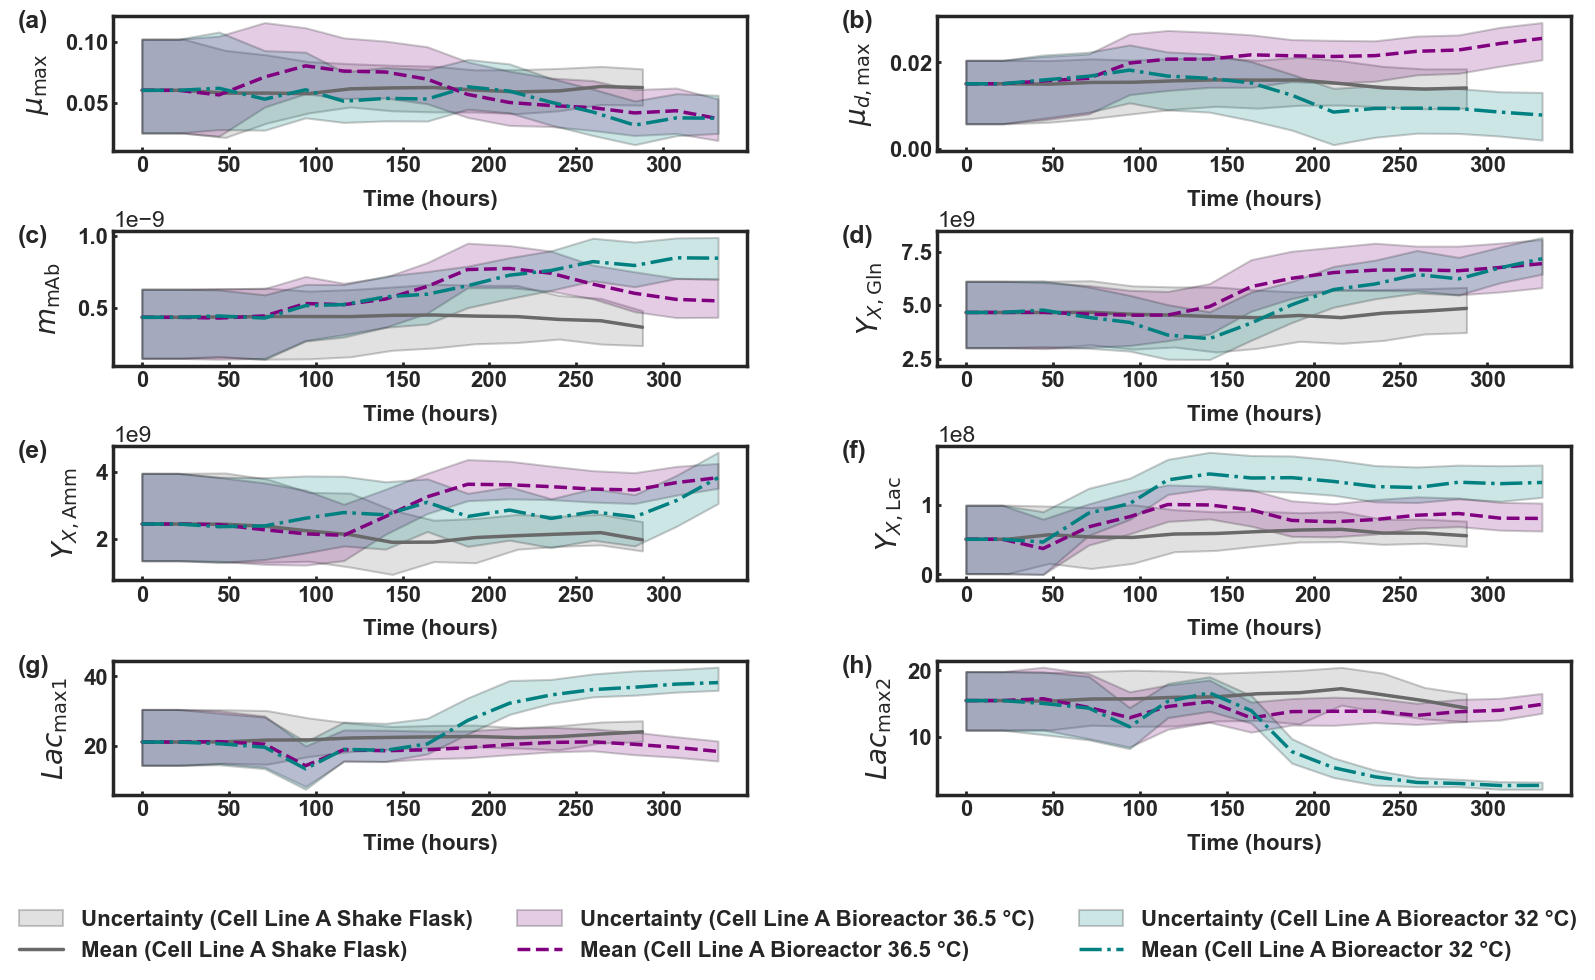

In [40]:
T127_datasets = ["CHO_T127_flask_PMJ", "CHO_T127_SNS_36.5", "CHO_T127_SNS_32"]
ensemble_size_list = [50, 50, 50]

selected_parameters = ['mu_max', 'mu_d_max', 'm_mAb' , 'Yx_gln', 'Yx_amm', 'Yx_lac', 'Lac_max_1', 'Lac_max_2' ]

legend_labels = [ 'Cell Line A Shake Flask', 'Cell Line A Bioreactor 36.5 °C', 'Cell Line A Bioreactor 32 °C']

colours = {
        "CHO_T127_flask_PMJ": "dimgray",    # Firebrick
          "CHO_T127_SNS_36.5": "purple",      # Dark Cyan
        "CHO_T127_SNS_32":  "teal"    # Midnight Blue
      
    }


plot_parameter_comparison_across_datasets(T127_datasets, ensemble_size_list, datasets, PX_records_best, 
                                          selected_keys=selected_parameters, 
                                          custom_legends=legend_labels, 
                                          filename="para_compare_scale.png",
                                          colours=colours)


Saved plot: para_compare_feed.png


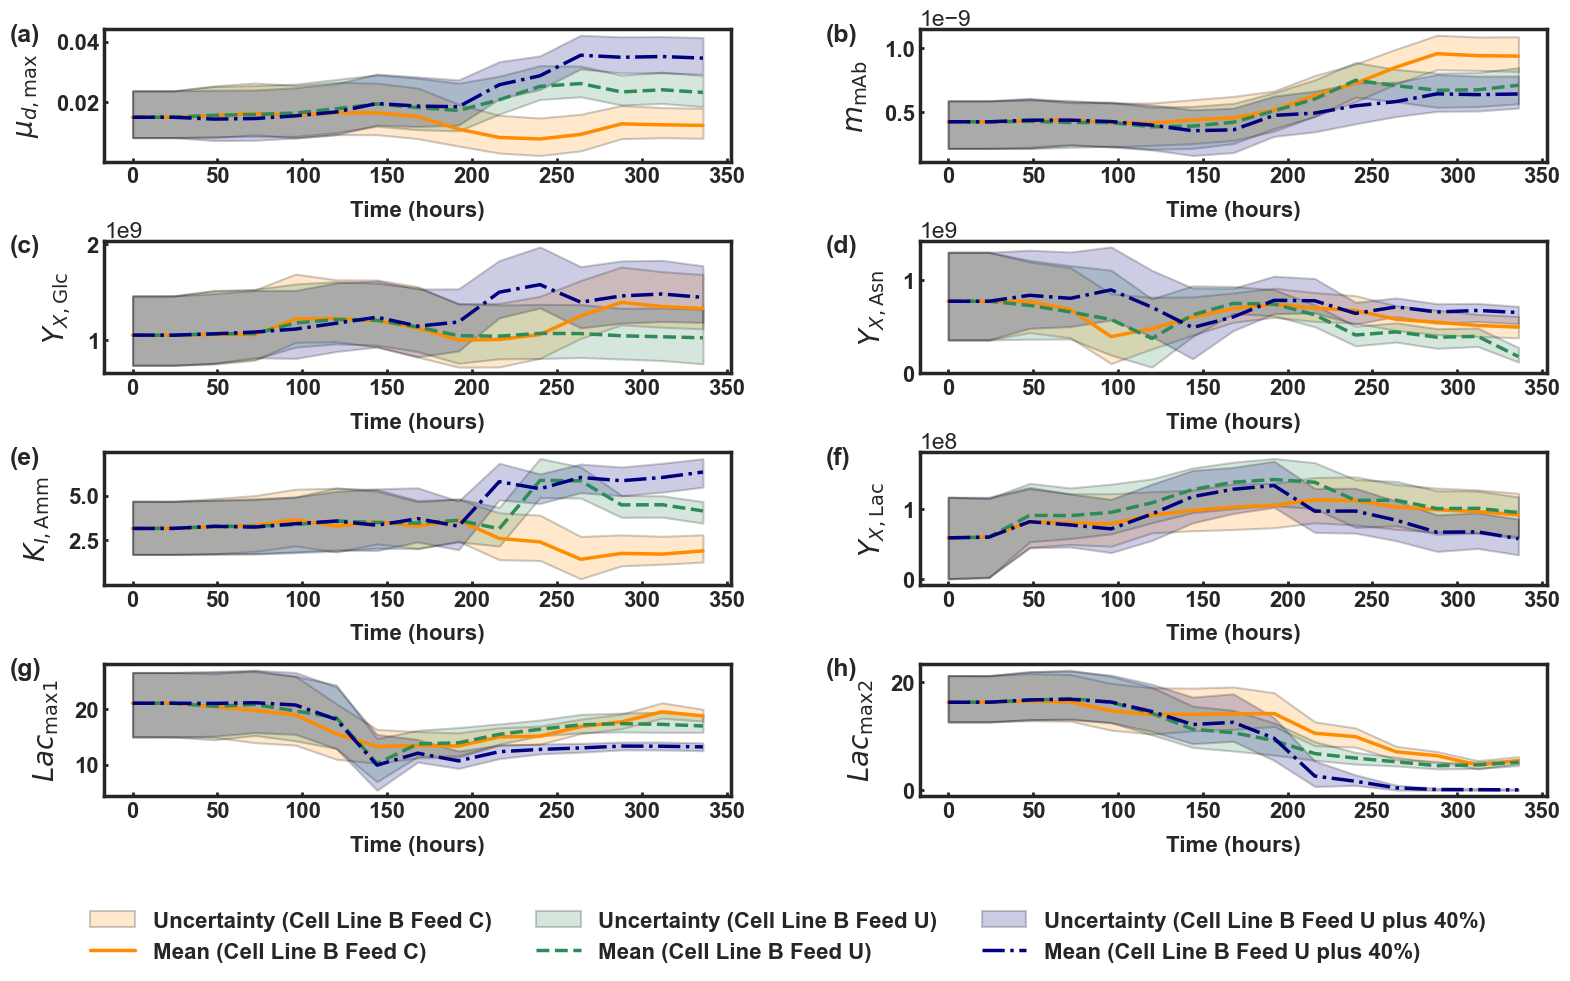

In [41]:
# Define datasets and their corresponding ensemble sizes
dataset_list = ['CHO_GS46_F_C_Inv', 'CHO_GS46_F_all', 'CHO_GS46_F_all_pl40']
ensemble_size_list = [75, 75, 75]

# Select specific parameters to compare
selected_parameters = ['mu_d_max', 'm_mAb', 'Yx_glc',  'Yx_asn', 'KIamm', 'Yx_lac', 
                       'Lac_max_1', 'Lac_max_2']

# Define custom legends
legend_labels = ['Cell Line B Feed C', 'Cell Line B Feed U', 'Cell Line B Feed U plus 40%']

# Define custom colours for GS46 datasets
colours = {
        "CHO_GS46_F_C_Inv": "darkorange",
        "CHO_GS46_F_all": "seagreen",
        "CHO_GS46_F_all_pl40": "navy"
    }
# Call the function with the custom colours
plot_parameter_comparison_across_datasets(dataset_list, 
                                          ensemble_size_list, 
                                          datasets, 
                                          PX_records_best, 
                                          selected_keys=selected_parameters, 
                                          custom_legends=legend_labels, 
                                          filename="para_compare_feed.png",
                                          colours=colours)